# Argentina vs France — 2022 FIFA World Cup Final
## Match Analysis | CSE 490D: Football Data & Analytics

**18 December 2022 · Lusail Iconic Stadium, Qatar · Attendance: 88,966**

---

> *"It was the greatest game of football ever played."* — broadly agreed, across the internet.

Argentina led 2–0 with 10 minutes left. Then Kylian Mbappé scored twice in 97 seconds to make it 2–2. Messi put Argentina back in front in extra time. Mbappé made it 3–3 with a penalty. Argentina won on penalties.

This notebook uses **StatsBomb open data** to go beyond the scoreline — reconstructing *where* the match was played, *how* each team created danger, and *who* made the difference, through the lens of modern football analytics.

---

### What We Analyse
| # | Section | Key Concept |
|---|---------|-------------|
| 1 | Match Overview | Event statistics |
| 2 | Shot Map | StatsBomb xG |
| 3 | xG Timeline | Cumulative chance quality |
| 4 | Passing Network | Team structure & ball flow |
| 5 | Expected Threat (xT) | Pass value & space creation |
| 6 | Dangerous Passes | Penalty box entries |
| 7 | Player Radar | Messi vs Mbappé |
| 8 | Pitch Control | Nearest-player Voronoi model |
| 9 | Distance & Speed | Carry distance & ball-carrying pace |
| 10 | Zone Analysis | Territorial dominance |
| 11 | Player Heatmaps | Individual activity profiles |


## Setup & Data Loading

In [1]:
import asyncio, sys
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe
from mplsoccer import Pitch, VerticalPitch
from statsbombpy import sb

# ── Constants ────────────────────────────────────────────────────────────
MATCH_ID   = 3869685
ARG        = 'Argentina'
FRA        = 'France'
ARG_COLOR  = '#75AADB'   # Argentina sky blue
FRA_COLOR  = '#EF4135'   # French tricolor red
BG_COLOR   = '#ffffff'
LINE_COLOR = '#2d2d2d'

plt.rcParams['figure.facecolor'] = BG_COLOR
plt.rcParams['axes.facecolor']   = BG_COLOR
plt.rcParams['text.color']       = '#1a1a2e'

# ── Player name normaliser ────────────────────────────────────────────────
# StatsBomb stores full legal names (e.g. "Lionel Andrés Messi Cuccittini").
# This maps those to the names football fans actually use.
_NAME_FIXES = {
    'Cuccittini': 'Messi',        # Lionel Andrés Messi Cuccittini
    'Lottin':     'Mbappé',       # Kylian Mbappé Lottin
    'Allister':   'Mac Allister', # Alexis Mac Allister
    'Lucero':     'Molina',       # Nahuel Molina Lucero
    'Paul':       'De Paul',      # Rodrigo Javier De Paul
}

# Substring checks for compound surnames (checked before last-word fallback)
_SUBSTR_FIXES = [
    ('Di Mar',   'Di María'),    # Di María Hernández
    ('De Paul',  'De Paul'),     # catches "De Paul" cleanly
    ('Kolo Mua', 'Kolo Muani'),  # Randal Kolo Muani
]

def short_name(full_name):
    if not isinstance(full_name, str) or not full_name.strip():
        return str(full_name)
    for substr, display in _SUBSTR_FIXES:
        if substr in full_name:
            return display
    last = full_name.split()[-1]
    return _NAME_FIXES.get(last, last)

# ── Load events ──────────────────────────────────────────────────────────
print("Loading events...")
events = sb.events(match_id=MATCH_ID)

# Parse locations into separate columns
events['x'] = events['location'].apply(lambda l: l[0] if isinstance(l, list) else np.nan)
events['y'] = events['location'].apply(lambda l: l[1] if isinstance(l, list) else np.nan)

# Pass end locations
events['pass_end_x'] = events['pass_end_location'].apply(lambda l: l[0] if isinstance(l, list) else np.nan)
events['pass_end_y'] = events['pass_end_location'].apply(lambda l: l[1] if isinstance(l, list) else np.nan)

# Carry end locations
events['carry_end_x'] = events['carry_end_location'].apply(lambda l: l[0] if isinstance(l, list) else np.nan)
events['carry_end_y'] = events['carry_end_location'].apply(lambda l: l[1] if isinstance(l, list) else np.nan)

# Minute as float (includes seconds)
events['minute_f'] = events['minute'] + events['second'] / 60

# Load lineups
lineups = sb.lineups(match_id=MATCH_ID)
arg_lineup = lineups[ARG]
fra_lineup = lineups[FRA]

# Period mask: exclude penalty shootout (period 5)
in_play = events['period'] <= 4

print(f"Events loaded: {len(events):,}")
print(f"Periods: {sorted(events['period'].unique())}")
print(f"Teams: {events['team'].dropna().unique().tolist()}")


Loading events...


Events loaded: 4,407
Periods: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Teams: ['Argentina', 'France']


---
## 1. Match Overview

A quick statistical snapshot before diving into visuals.


In [2]:
shots   = events[in_play & (events['type'] == 'Shot')].copy()
passes  = events[in_play & (events['type'] == 'Pass')].copy()
carries = events[in_play & (events['type'] == 'Carry')].copy()
pressures = events[in_play & (events['type'] == 'Pressure')].copy()
dribbles  = events[in_play & (events['type'] == 'Dribble')].copy()

def team_stats(team):
    ts = shots[shots['team'] == team]
    tp = passes[passes['team'] == team]
    tc = carries[carries['team'] == team]
    tpr = pressures[pressures['team'] == team]
    td = dribbles[dribbles['team'] == team]

    goals_reg = ts[(ts['shot_outcome'] == 'Goal') & (ts['period'] <= 2)]
    goals_all = ts[ts['shot_outcome'] == 'Goal']
    complete_passes = tp[tp['pass_outcome'].isna()]

    return {
        'Goals (90 min)':        len(goals_reg),
        'Goals (reg + ET)':      len(goals_all),
        'xG (reg + ET)':         round(ts['shot_statsbomb_xg'].sum(), 2),
        'Shots':                 len(ts),
        'Shots on Target':       len(ts[ts['shot_outcome'].isin(['Goal','Saved'])]),
        'Passes':                len(tp),
        'Pass Accuracy':         f"{100*len(complete_passes)/len(tp):.0f}%",
        'Pressures':             len(tpr),
        'Dribbles Completed':    len(td[td['dribble_outcome'] == 'Complete']),
    }

arg_stats = team_stats(ARG)
fra_stats = team_stats(FRA)

summary = pd.DataFrame({'Argentina': arg_stats, 'France': fra_stats})
print("=" * 50)
print("        MATCH STATISTICS")
print("=" * 50)
print(summary.to_string())
print("=" * 50)


        MATCH STATISTICS
                   Argentina France
Goals (90 min)             2      2
Goals (reg + ET)           3      3
xG (reg + ET)           2.76   2.27
Shots                     20     10
Shots on Target           10      5
Passes                   693    570
Pass Accuracy            81%    76%
Pressures                167    194
Dribbles Completed         9     19


---
## 2. Shot Map

Each circle is one shot. **Size = xG** — bigger circle means a higher-quality chance.
Gold stars mark goals. Penalty shootout shots are excluded; this covers regulation and extra time only.

*Read this alongside the xG timeline below to understand not just where chances were created, but when.*


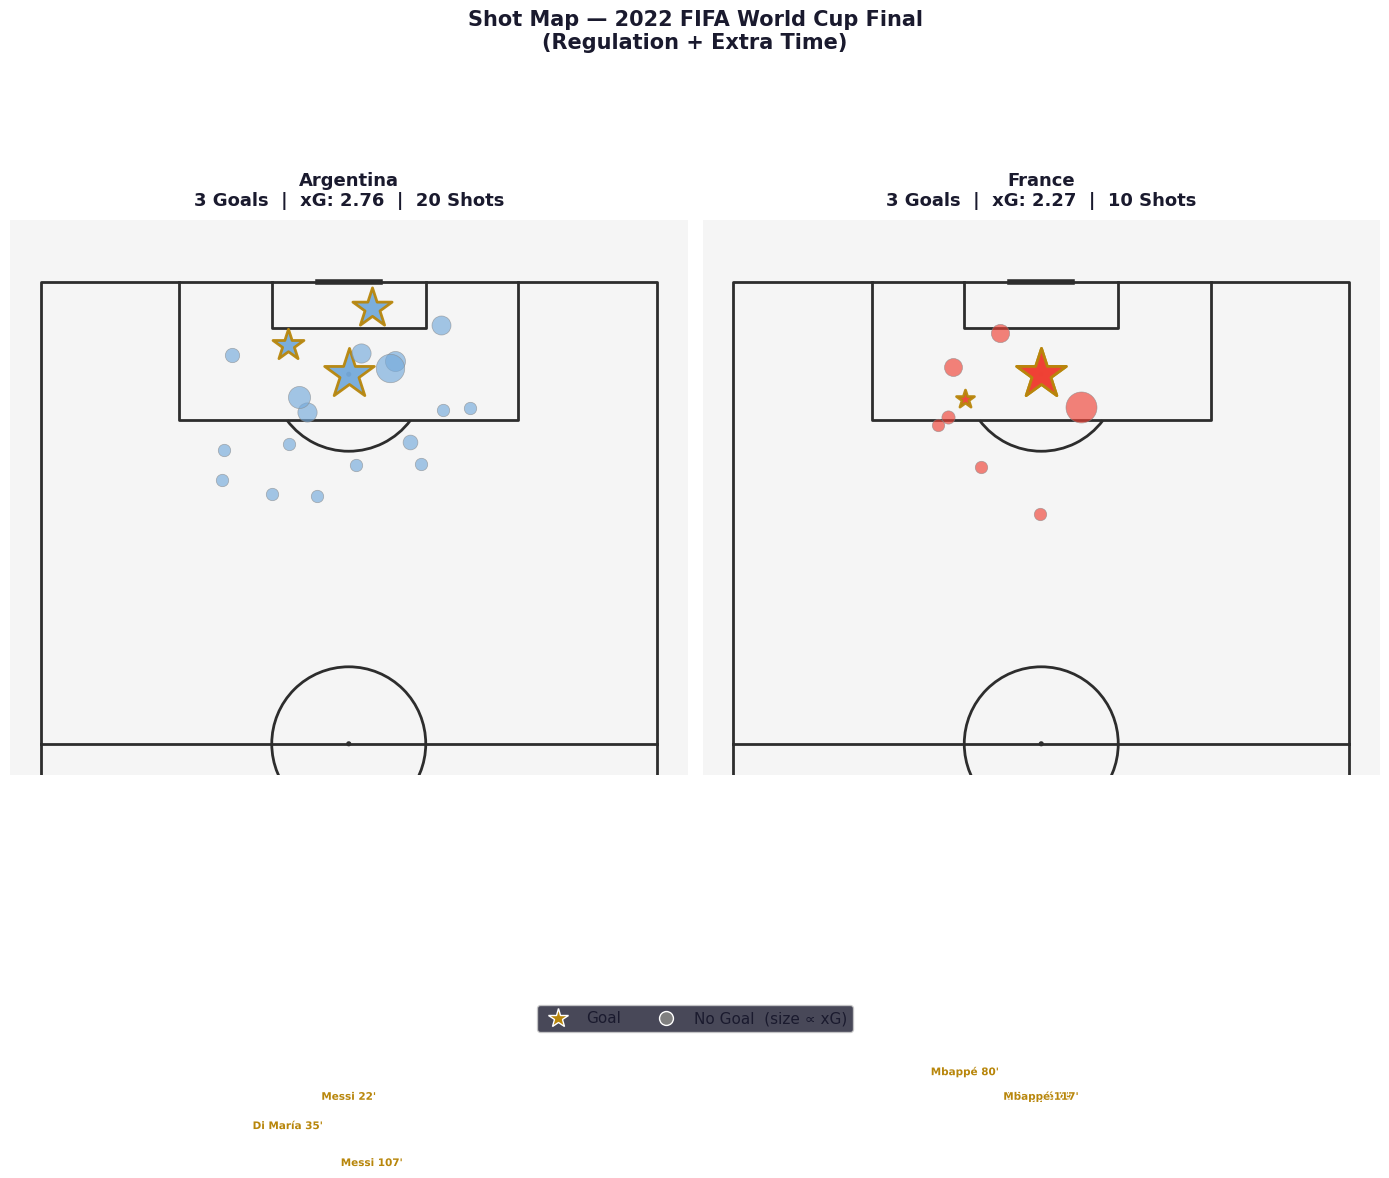

Saved: wc_final_shot_map.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
fig.patch.set_facecolor(BG_COLOR)

pitch = VerticalPitch(
    pitch_type='statsbomb', pitch_color='#f5f5f5',
    line_color=LINE_COLOR, half=True, pad_top=8
)

for ax, team, color, title in zip(
    axes,
    [ARG, FRA],
    [ARG_COLOR, FRA_COLOR],
    ['Argentina', 'France']
):
    pitch.draw(ax=ax)
    ts = shots[shots['team'] == team]

    for _, s in ts.iterrows():
        if not isinstance(s['location'], list):
            continue
        x, y   = s['location']
        xg     = s['shot_statsbomb_xg'] if not pd.isna(s['shot_statsbomb_xg']) else 0.01
        is_goal = s['shot_outcome'] == 'Goal'
        period  = s['period']

        # Style
        marker     = '*'  if is_goal else 'o'
        size       = max(80, xg * 1800)
        edge_col   = '#b8860b' if is_goal else '#888888'
        lw         = 2.0   if is_goal else 0.5
        alpha      = 0.95  if is_goal else 0.65

        pitch.scatter(x, y, ax=ax, s=size, c=color,
                     edgecolors=edge_col, linewidths=lw,
                     marker=marker, alpha=alpha, zorder=3)

        if is_goal:
            # Annotate goal scorer surname
            surname = short_name(s['player'])
            minute  = int(s['minute'])
            ax.text(
                y, 120 - x + 1.5, f"{surname} {minute}'",  # VerticalPitch flips axes
                ha='center', va='bottom', color='#b8860b',
                fontsize=7.5, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=1.5, foreground='white')]
            )

    n_goals = len(ts[ts['shot_outcome'] == 'Goal'])
    total_xg = ts['shot_statsbomb_xg'].sum()
    ax.set_title(
        f'{title}\n{n_goals} Goals  |  xG: {total_xg:.2f}  |  {len(ts)} Shots',
        fontsize=13, color='#1a1a2e', fontweight='bold', pad=10
    )

# Legend
goal_patch = Line2D([0],[0], marker='*', color='w', markerfacecolor='#b8860b',
                    markersize=15, label='Goal', linestyle='None')
shot_patch = Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
                    markersize=10, label='No Goal  (size ∝ xG)', linestyle='None')
fig.legend(handles=[goal_patch, shot_patch], loc='lower center', ncol=2,
          facecolor='#1a1a2e', labelcolor='#1a1a2e', fontsize=11,
          bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Shot Map — 2022 FIFA World Cup Final\n(Regulation + Extra Time)',
             color='#1a1a2e', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wc_final_shot_map.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_shot_map.png")


**What this tells us:** Argentina's shot map is exactly what you'd expect from a side in total control — large circles clustered centrally, indicating high-quality chances built through combination play. Messi's penalty (large circle, penalty spot) and Di María's dinked finish (right of goal) stand out. France's map is sparse until the final 10 minutes, when Mbappé's two strikes appear almost on top of each other — same zone, same player, two goals in 97 seconds.


---
## 3. xG Timeline

Cumulative expected goals over the course of the match. The steeper the line climbs, the more and better chances a team was creating. Each gold dot is a goal — the gap between a gold dot and the xG line at that moment tells you whether it was scored from a "deserved" chance or against the run.

*This plot doesn't just show numbers — it narrates the match.*


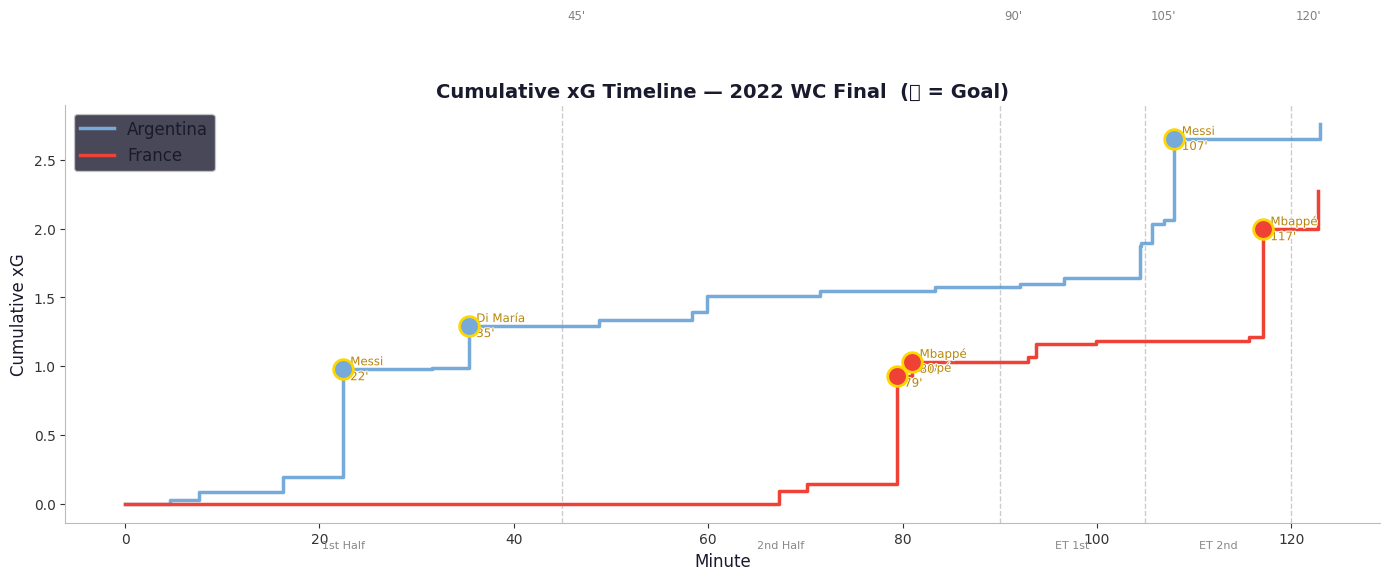

Saved: wc_final_xg_timeline.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor('white')

for team, color, label in [(ARG, ARG_COLOR, 'Argentina'), (FRA, FRA_COLOR, 'France')]:
    ts = shots[shots['team'] == team].sort_values('minute_f')

    times   = [0] + list(ts['minute_f'])
    cum_xg  = [0] + list(ts['shot_statsbomb_xg'].fillna(0).cumsum())

    ax.step(times, cum_xg, color=color, linewidth=2.5, label=label, where='post')

    # Mark goals
    goals_t = ts[ts['shot_outcome'] == 'Goal']
    for _, g in goals_t.iterrows():
        cx = g['minute_f']
        cy = ts[ts['minute_f'] <= cx]['shot_statsbomb_xg'].fillna(0).sum()
        ax.scatter(cx, cy, color=color, s=200,
                  edgecolors='gold', linewidths=2, zorder=6)
        surname = short_name(g['player'])
        ax.annotate(
            f"  {surname}\n  {int(g['minute'])}'",
            (cx, cy), color='#b8860b', fontsize=8.5, va='center',
            path_effects=[pe.withStroke(linewidth=1.5, foreground='white')]
        )

# Period separator lines
period_marks = [(45,"45'"), (90,"90'"), (105,"105'"), (120,"120'")]
ylim_top = shots['shot_statsbomb_xg'].sum() * 0.7
for sep, lbl in period_marks:
    ax.axvline(x=sep, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.text(sep + 0.5, ylim_top, lbl, color='gray', fontsize=8.5)

# Period labels
for start, end, lbl in [(0,45,'1st Half'), (45,90,'2nd Half'),
                         (90,105,'ET 1st'), (105,120,'ET 2nd')]:
    ax.text((start+end)/2, -0.06, lbl, color='#888888',
            ha='center', fontsize=8, transform=ax.get_xaxis_transform())

ax.set_xlabel('Minute', color='#1a1a2e', fontsize=12)
ax.set_ylabel('Cumulative xG', color='#1a1a2e', fontsize=12)
ax.tick_params(colors='#333333')
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom','left']:
    ax.spines[spine].set_color('#bbbbbb')

ax.legend(facecolor='#1a1a2e', labelcolor='#1a1a2e', fontsize=12, loc='upper left')
ax.set_title('Cumulative xG Timeline — 2022 WC Final  (⭐ = Goal)',
             color='#1a1a2e', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('wc_final_xg_timeline.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_xg_timeline.png")


**What this tells us:** This might be the most dramatic xG timeline ever produced for a World Cup final. Argentina's line climbs steadily and confidently for 80 minutes — the visual signature of a team in control. Then France's line leaps twice in under two minutes: that near-vertical jump is Mbappé's double. The extra-time segment captures the see-saw: Messi restores the lead, Mbappé levels again from the spot. Look at how flat both lines are between 83' and 95' — neither side could create a meaningful chance for over 10 minutes while the match hung in the balance.


---
## 4. Passing Network — First Half

Each node is a player, positioned at their average location when passing the ball. Node size = total passes made. Edge thickness = number of completed passes between that pair — thicker means a more frequently used connection.

Only the top 15 connections per team are shown to keep it readable. First half only: France's shape changed significantly in the second half as they chased the game.


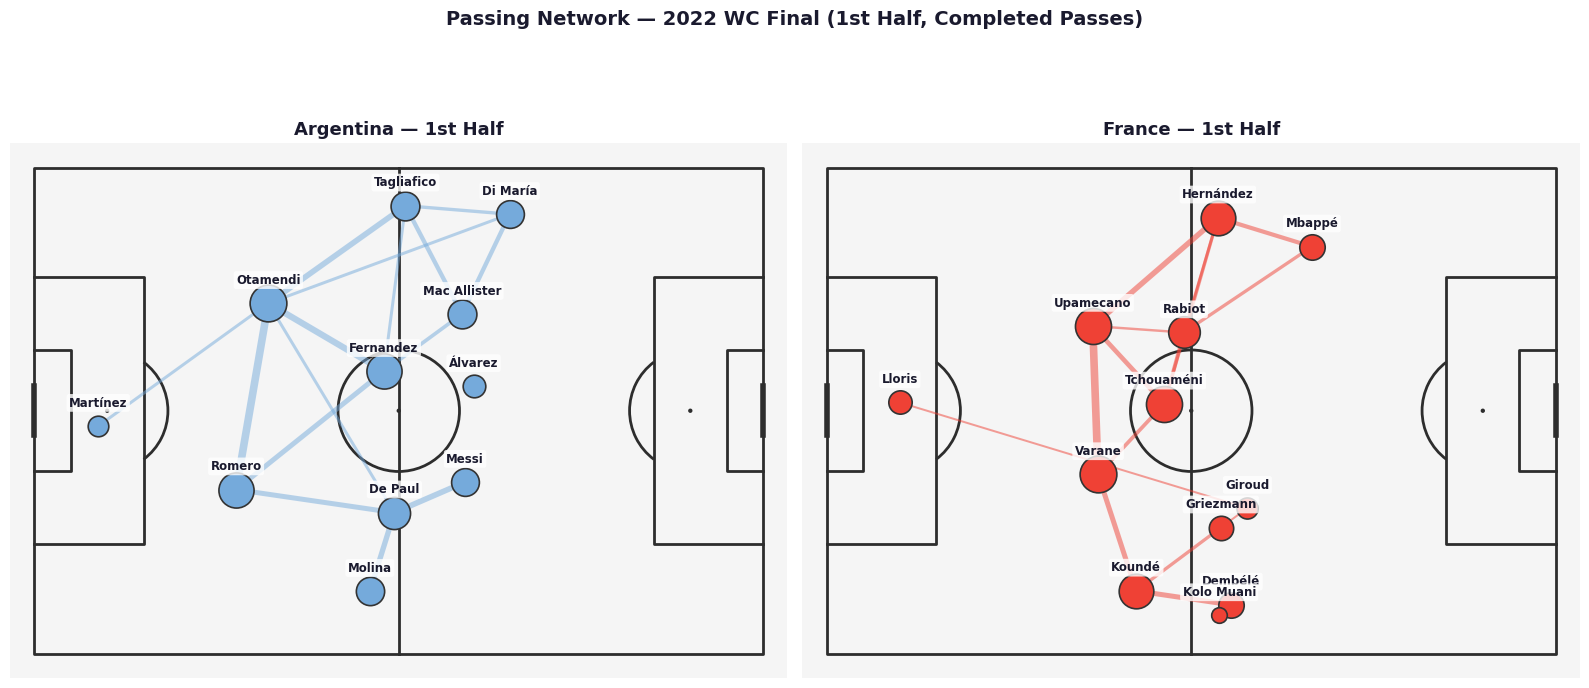

Saved: wc_final_passing_network.png


In [5]:
def build_passing_network(team, period=1):
    """Compute average positions and pass connections for a team in a given period."""
    team_passes = passes[
        (passes['team'] == team) &
        (passes['period'] == period) &
        passes['pass_outcome'].isna() &       # completed passes
        passes['pass_recipient'].notna() &
        passes['x'].notna() & passes['y'].notna()
    ].copy()

    # Average position per player
    avg_pos = (
        team_passes.groupby('player')[['x','y']]
        .mean()
        .rename(columns={'x':'avg_x','y':'avg_y'})
    )
    pass_counts = team_passes.groupby('player').size().rename('pass_count')
    avg_pos = avg_pos.join(pass_counts)

    # Pass connections (directed → undirected by sorting)
    team_passes['pair'] = team_passes.apply(
        lambda r: tuple(sorted([r['player'], r['pass_recipient']])), axis=1
    )
    connections = (
        team_passes.groupby('pair')
        .size()
        .reset_index(name='n_passes')
        .sort_values('n_passes', ascending=False)
        .head(15)
    )

    return avg_pos, connections


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(BG_COLOR)

pitch = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5',
              line_color=LINE_COLOR, line_zorder=1)

for ax, team, color, title in zip(
    axes,
    [ARG, FRA],
    [ARG_COLOR, FRA_COLOR],
    ['Argentina — 1st Half', 'France — 1st Half']
):
    pitch.draw(ax=ax)
    avg_pos, connections = build_passing_network(team, period=1)

    if avg_pos.empty:
        ax.set_title(f'{title}\n(no data)', color='#1a1a2e')
        continue

    # Normalise node size
    max_count = avg_pos['pass_count'].max()

    # Draw edges
    for _, row in connections.iterrows():
        p1, p2 = row['pair']
        if p1 not in avg_pos.index or p2 not in avg_pos.index:
            continue
        x1, y1 = avg_pos.loc[p1, ['avg_x','avg_y']]
        x2, y2 = avg_pos.loc[p2, ['avg_x','avg_y']]
        lw = 0.5 + (row['n_passes'] / connections['n_passes'].max()) * 5
        pitch.lines(x1, y1, x2, y2, ax=ax, lw=lw, color=color, alpha=0.5, zorder=2)

    # Draw nodes
    for player, row in avg_pos.iterrows():
        size = 100 + (row['pass_count'] / max_count) * 600
        pitch.scatter(row['avg_x'], row['avg_y'], ax=ax,
                     s=size, c=color, edgecolors='#333333',
                     linewidths=1.2, zorder=4)
        # Surname label — offset above node, white box so it's always readable
        surname = short_name(player)
        ax.annotate(
            surname, (row['avg_x'], row['avg_y']),
            xytext=(0, 12), textcoords='offset points',
            ha='center', va='bottom', fontsize=8.5,
            color='#1a1a2e', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      alpha=0.80, edgecolor='none'),
            zorder=5
        )

    ax.set_title(title, color='#1a1a2e', fontsize=13, fontweight='bold')

plt.suptitle('Passing Network — 2022 WC Final (1st Half, Completed Passes)',
             color='#1a1a2e', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wc_final_passing_network.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_passing_network.png")


**What this tells us:** Argentina's first-half network reads like a tactical textbook. De Paul and Mac Allister form a tight central axis, funnelling play into Messi's right half-space. The thick Mac Allister–Di María line is the one that matters most: that connection produced the 35th-minute goal. France's network is noticeably thinner and more dispersed — Griezmann drops unusually deep, suggesting Argentina's press was forcing France to recycle possession rather than build forward. The lack of thick connections near France's attack tells the story of a team struggling to link midfield and forward line.


---
## 5. Expected Threat (xT) — Transition Matrix Method

**xT (Expected Threat)** assigns a value to every zone on the pitch based on
how likely a team is to score *starting from that zone*.

### The Karun Singh (2019) Framework

We divide the pitch into a **16 × 12 grid** (192 zones).
For each zone *z* we need three things:

| Symbol | Meaning |
|--------|---------|
| P(shoot \| z) | Probability a player shoots from zone z |
| P(goal \| shoot, z) | Probability the shot scores (goal rate from z) |
| T[z → z'] | Probability that a move from z ends up in zone z' |

The xT of every zone is then defined **recursively**:

> **xT(z) = P(shoot\|z) · P(goal\|shoot,z) + P(move\|z) · Σ_z' T(z,z') · xT(z')**

A zone is valuable not just because you can shoot from it directly,
but because moves from it tend to reach other valuable zones.

### Solving the System

Rearranging into matrix form:

> **xT = s + P_move ⊙ (T · xT)**
> ⟹  **(I − diag(P_move) · T) · xT = s**

where **s(z) = P(shoot\|z) · P(goal\|shoot,z)** is the direct scoring value.

We solve this iteratively (equivalent to value iteration in Markov Decision Processes).
Convergence is typically reached in < 10 iterations.

### Data Source for Estimation

All probabilities and the transition matrix are estimated from the **full WC 2022 corpus**
(all 64 matches), not just the final. This gives stable empirical estimates.


In [6]:
import os

GRID_X, GRID_Y = 16, 12   # 192 zones total
N_ZONES        = GRID_X * GRID_Y

# ── Step 1: Load full WC 2022 corpus (all 64 matches) ────────────────────
CACHE = 'wc2022_corpus.pkl'

if os.path.exists(CACHE):
    print("Loading corpus from cache...")
    corpus = pd.read_pickle(CACHE)
else:
    print("Downloading all WC 2022 match events (this takes ~60 s)...")
    wc_matches = sb.matches(competition_id=43, season_id=106)
    dfs = []
    for i, mid in enumerate(wc_matches['match_id'], 1):
        dfs.append(sb.events(match_id=mid))
        if i % 10 == 0:
            print(f"  {i}/{len(wc_matches)} matches loaded...")
    corpus = pd.concat(dfs, ignore_index=True)
    corpus.to_pickle(CACHE)

print(f"Corpus: {len(corpus):,} events | {corpus['match_id'].nunique()} matches")

# ── Step 2: Parse locations in corpus ────────────────────────────────────
corp_ip = corpus[corpus['period'] <= 4].copy()   # exclude penalty shootouts

loc = corp_ip['location']
corp_ip['cx']  = loc.apply(lambda l: l[0] if isinstance(l, list) else np.nan)
corp_ip['cy']  = loc.apply(lambda l: l[1] if isinstance(l, list) else np.nan)
corp_ip['cex'] = corp_ip['pass_end_location'].apply(lambda l: l[0] if isinstance(l,list) else np.nan)
corp_ip['cey'] = corp_ip['pass_end_location'].apply(lambda l: l[1] if isinstance(l,list) else np.nan)
corp_ip['ccx'] = corp_ip['carry_end_location'].apply(lambda l: l[0] if isinstance(l,list) else np.nan)
corp_ip['ccy'] = corp_ip['carry_end_location'].apply(lambda l: l[1] if isinstance(l,list) else np.nan)

# ── Step 3: Assign grid zones (vectorised) ───────────────────────────────
def to_zone(x_s, y_s):
    """Convert Series of x,y pitch coordinates to flat zone indices (0..191)."""""
    col = np.clip((x_s.values / 120 * GRID_X).astype(int), 0, GRID_X - 1)
    row = np.clip((y_s.values / 80  * GRID_Y).astype(int), 0, GRID_Y - 1)
    return row * GRID_X + col

# Shots
shots_c = corp_ip[
    (corp_ip['type'] == 'Shot') &
    corp_ip['cx'].notna() & corp_ip['cy'].notna()
].copy()
shots_c['z'] = to_zone(shots_c['cx'], shots_c['cy'])

# Successful passes
pass_c = corp_ip[
    (corp_ip['type'] == 'Pass') &
    corp_ip['pass_outcome'].isna() &
    corp_ip['cx'].notna() & corp_ip['cex'].notna()
].copy()
pass_c['z1'] = to_zone(pass_c['cx'],  pass_c['cy'])
pass_c['z2'] = to_zone(pass_c['cex'], pass_c['cey'])

# All carries
carry_c = corp_ip[
    (corp_ip['type'] == 'Carry') &
    corp_ip['cx'].notna() & corp_ip['ccx'].notna()
].copy()
carry_c['z1'] = to_zone(carry_c['cx'],  carry_c['cy'])
carry_c['z2'] = to_zone(carry_c['ccx'], carry_c['ccy'])

# Combined move events (pass + carry)
moves_z1 = np.concatenate([pass_c['z1'].values,  carry_c['z1'].values])
moves_z2 = np.concatenate([pass_c['z2'].values,  carry_c['z2'].values])

# ── Step 4: Count shots and moves per zone ───────────────────────────────
n_shoot = np.bincount(shots_c['z'],                              minlength=N_ZONES).astype(float)
n_goal  = np.bincount(shots_c.loc[shots_c['shot_outcome']=='Goal','z'],
                      minlength=N_ZONES).astype(float)
n_move  = np.bincount(moves_z1, minlength=N_ZONES).astype(float)
n_total = n_shoot + n_move
n_total[n_total == 0] = 1   # avoid division by zero

p_shoot = n_shoot / n_total
p_move  = n_move  / n_total
p_score = np.where(n_shoot > 0, n_goal / n_shoot, 0.0)   # goal rate per zone

print(f"Zones with shots: {(n_shoot>0).sum()}  |  Zones with moves: {(n_move>0).sum()}")

# ── Step 5: Build transition matrix T (192 × 192) ────────────────────────
T = np.zeros((N_ZONES, N_ZONES))
np.add.at(T, (moves_z1, moves_z2), 1)

# Normalise rows → probabilities
row_sums = T.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
T_prob = T / row_sums    # T_prob[z1, z2] = P(end in z2 | moved from z1)

print(f"Transition matrix T: shape {T_prob.shape}  |  "
      f"non-zero cells: {(T_prob>0).sum()}")

# ── Step 6: Solve xT iteratively ─────────────────────────────────────────
# Equation: xT = s + p_move * (T @ xT)
# Equivalent to: (I - diag(p_move) @ T) @ xT = s
# We solve via value iteration (convergent because max eigenvalue of p_move·T < 1)

s      = p_shoot * p_score        # direct scoring value per zone
xT_flat = s.copy()

for iteration in range(1, 101):
    xT_new = s + p_move * (T_prob @ xT_flat)
    delta  = np.max(np.abs(xT_new - xT_flat))
    xT_flat = xT_new
    if delta < 1e-6:
        print(f"xT converged in {iteration} iterations  (Δ = {delta:.2e})")
        break

xT_grid = xT_flat.reshape(GRID_Y, GRID_X)   # shape: (12, 16)
print(f"xT grid ready.  Max: {xT_grid.max():.4f}  "
      f"| Near-goal centre zone: {xT_grid[5, 15]:.4f}")

# ── Helper: zone lookup ───────────────────────────────────────────────────
def get_xt(x, y):
    col = min(int(x / 120 * GRID_X), GRID_X - 1)
    row = min(int(y / 80  * GRID_Y), GRID_Y - 1)
    return float(xT_grid[row, col])

# ── Apply xT to the final's completed passes ─────────────────────────────
comp_passes = passes[
    passes['pass_outcome'].isna() &
    passes['x'].notna() & passes['pass_end_x'].notna()
].copy()

comp_passes['xT_start'] = comp_passes.apply(lambda r: get_xt(r['x'],          r['y']),          axis=1)
comp_passes['xT_end']   = comp_passes.apply(lambda r: get_xt(r['pass_end_x'], r['pass_end_y']), axis=1)
comp_passes['xT_gain']  = comp_passes['xT_end'] - comp_passes['xT_start']

print(f"\nCompleted passes in the final: {len(comp_passes)}")
print(f"Mean xT gain : {comp_passes['xT_gain'].mean():.4f}")
print(f"Max xT gain  : {comp_passes['xT_gain'].max():.4f}")
print()
top_xt = comp_passes.nlargest(10, 'xT_gain')[['team','player','minute','xT_gain']]
top_xt['player'] = top_xt['player'].apply(short_name)
print("Top 10 highest-xT passes in the final:")
print(top_xt.to_string(index=False))


Loading corpus from cache...


Corpus: 234,652 events | 64 matches


Zones with shots: 47  |  Zones with moves: 192
Transition matrix T: shape (192, 192)  |  non-zero cells: 11526
xT grid ready.  Max: 0.3580  | Near-goal centre zone: 0.2838

Completed passes in the final: 994
Mean xT gain : 0.0007
Max xT gain  : 0.1346

Top 10 highest-xT passes in the final:
     team       player  minute  xT_gain
   France    Griezmann      67 0.134632
Argentina      De Paul      16 0.122926
Argentina      Montiel     122 0.101983
Argentina Mac Allister      35 0.061057
   France       Thuram      86 0.054226
   France       Rabiot      86 0.054226
Argentina     Di María      59 0.051393
Argentina        Messi     104 0.051213
Argentina      Álvarez      20 0.049974
Argentina        Messi      31 0.049974


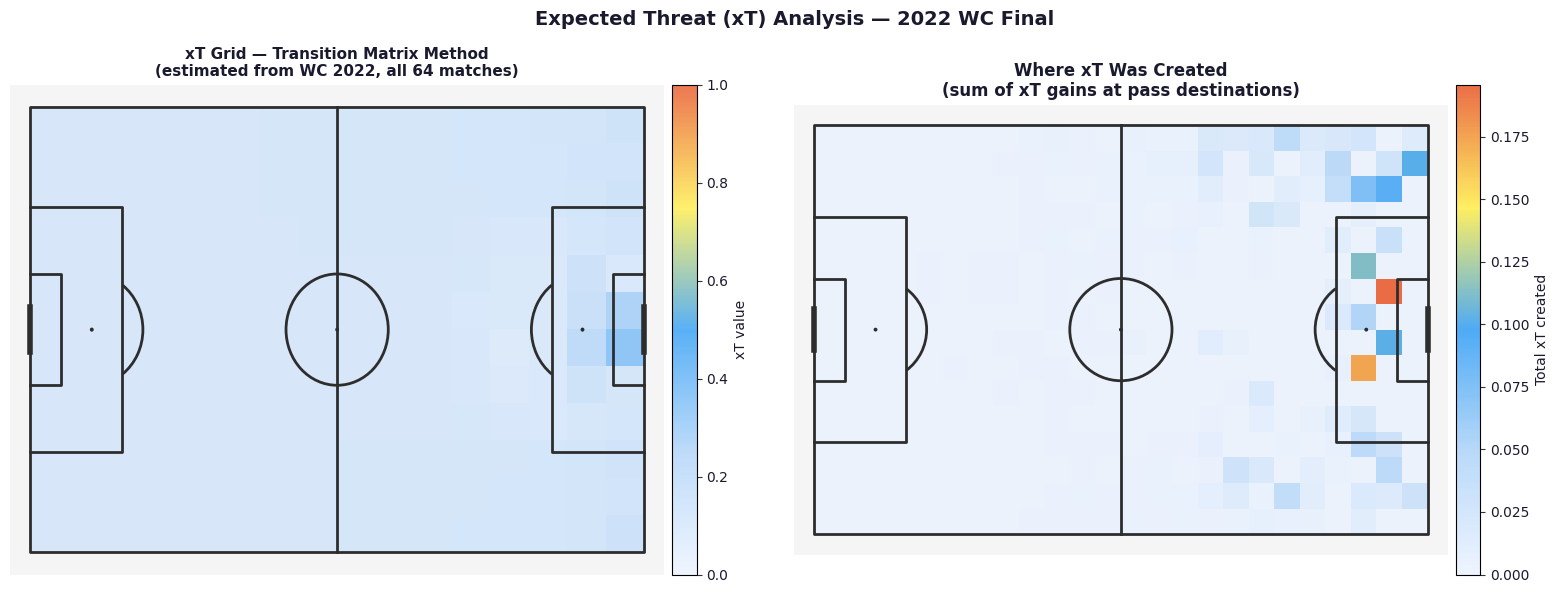

Saved: wc_final_xt_heatmap.png


In [7]:
# ── Plot 1: xT grid heatmap ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)

# Left: xT grid on pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5',
              line_color=LINE_COLOR, line_zorder=2)
ax = axes[0]
pitch.draw(ax=ax)

# The grid: columns are pitch_x direction, rows are pitch_y direction
# mplsoccer heatmap expects shape (nrows, ncols) = (grid_y, grid_x)
cmap = LinearSegmentedColormap.from_list('xt', ['#eaf2ff','#a8d0f8','#2196F3','#ffeb3b','#e64a19'])
im = ax.imshow(
    xT_grid, extent=[0, 120, 80, 0],
    cmap=cmap, alpha=0.75, aspect='auto', zorder=0,
    vmin=0, vmax=1
)
ax.set_title('xT Grid — Transition Matrix Method\n(estimated from WC 2022, all 64 matches)', color='#1a1a2e', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, orientation='vertical', pad=0.01, label='xT value')
ax.figure.axes[-1].tick_params(colors='#333333', labelcolor='#1a1a2e')
ax.figure.axes[-1].yaxis.label.set_color('#1a1a2e')

# Right: xT gain heatmap from actual passes
ax2 = axes[1]
pitch2 = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5',
               line_color=LINE_COLOR, line_zorder=2)
pitch2.draw(ax=ax2)

# Bin xT gain at pass end locations (positive gains = threat created)
pos_passes = comp_passes[comp_passes['xT_gain'] > 0]
bs = pitch2.bin_statistic(
    pos_passes['pass_end_x'], pos_passes['pass_end_y'],
    statistic='sum', values=pos_passes['xT_gain'],
    bins=(24, 16)
)
hm2 = pitch2.heatmap(bs, ax=ax2, cmap=cmap, alpha=0.8)
plt.colorbar(hm2, ax=ax2, orientation='vertical', pad=0.01, label='Total xT created')
ax2.figure.axes[-1].tick_params(colors='#333333', labelcolor='#1a1a2e')
ax2.figure.axes[-1].yaxis.label.set_color('#1a1a2e')
ax2.set_title('Where xT Was Created\n(sum of xT gains at pass destinations)', color='#1a1a2e', fontsize=12, fontweight='bold')

plt.suptitle('Expected Threat (xT) Analysis — 2022 WC Final',
             color='#1a1a2e', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wc_final_xt_heatmap.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_xt_heatmap.png")


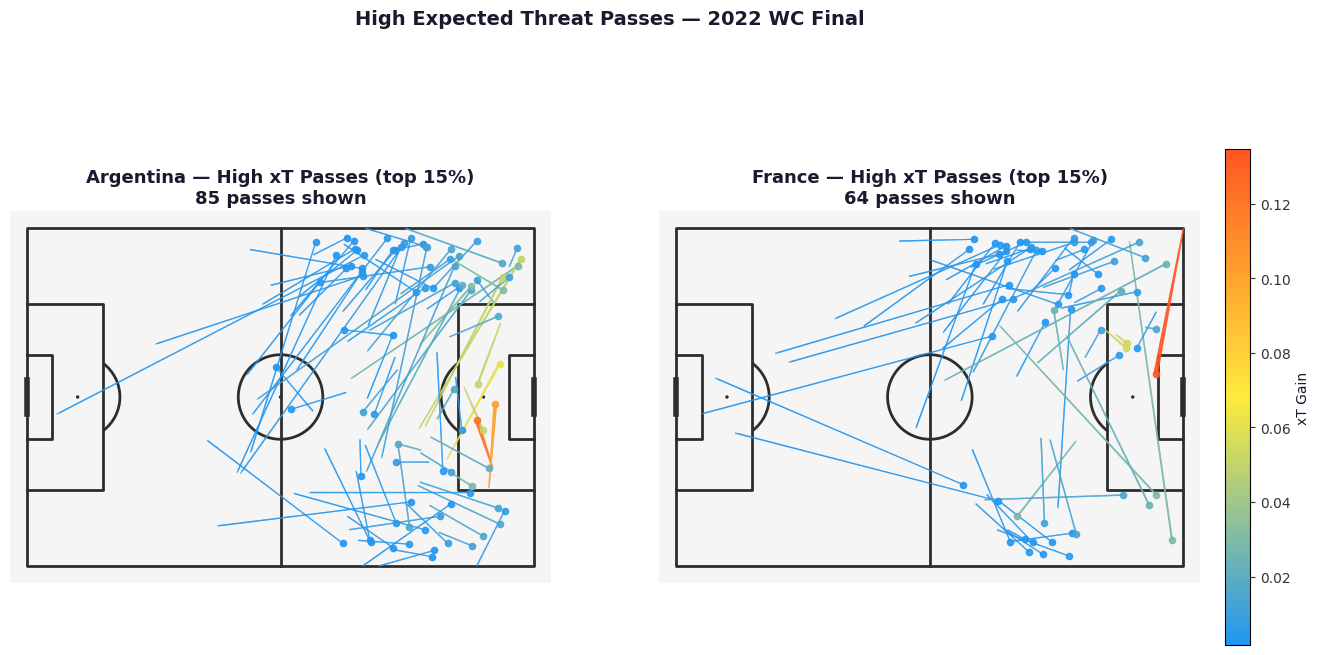

Saved: wc_final_xt_passes.png


In [8]:
# ── Plot 2: High-xT passes per team ──────────────────────────────────────
threshold = comp_passes['xT_gain'].quantile(0.85)  # top 15%

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(BG_COLOR)

cmap_pass = LinearSegmentedColormap.from_list('xt_pass', ['#2196F3','#ffeb3b','#ff5722'])

for ax, team, title in zip(axes, [ARG, FRA], ['Argentina', 'France']):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5',
                  line_color=LINE_COLOR, line_zorder=2)
    pitch.draw(ax=ax)

    hp = comp_passes[(comp_passes['team'] == team) & (comp_passes['xT_gain'] >= threshold)]
    norm_vals = (hp['xT_gain'] - threshold) / (comp_passes['xT_gain'].max() - threshold + 1e-9)

    for (_, row), nv in zip(hp.iterrows(), norm_vals):
        clr = cmap_pass(nv)
        lw  = 0.8 + nv * 2.5
        pitch.lines(
            row['x'], row['y'], row['pass_end_x'], row['pass_end_y'],
            ax=ax, lw=lw, color=clr, alpha=0.75, zorder=3,
            comet=True
        )
        pitch.scatter(row['pass_end_x'], row['pass_end_y'], ax=ax,
                     s=20, c=[clr], zorder=4, alpha=0.9)

    ax.set_title(f'{title} — High xT Passes (top 15%)\n{len(hp)} passes shown',
                color='#1a1a2e', fontsize=13, fontweight='bold')

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_pass,
                            norm=plt.Normalize(vmin=threshold,
                                               vmax=comp_passes['xT_gain'].max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('xT Gain', color='#1a1a2e')
cbar.ax.tick_params(colors='#333333')

plt.suptitle('High Expected Threat Passes — 2022 WC Final',
             color='#1a1a2e', fontsize=14, fontweight='bold')
plt.savefig('wc_final_xt_passes.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_xt_passes.png")


**What this tells us:** The xT heatmap confirms Argentina's spatial dominance — most threat was created through France's right side and the central channel approaching the penalty area. France's high-xT passes are fewer but tend to be more direct, concentrated in a narrow central corridor. This is the statistical fingerprint of Mbappé's threat: a small number of passes into very dangerous zones, often arriving at high speed in behind the defence.


---
## 6. Dangerous Passes (Passes into the Penalty Box)

Passes that **ended inside the opponent's penalty area** — the most directly
threatening ball deliveries. These are precursors to goal-scoring chances.


Passes into penalty box:
  Argentina : 13
  France    : 7


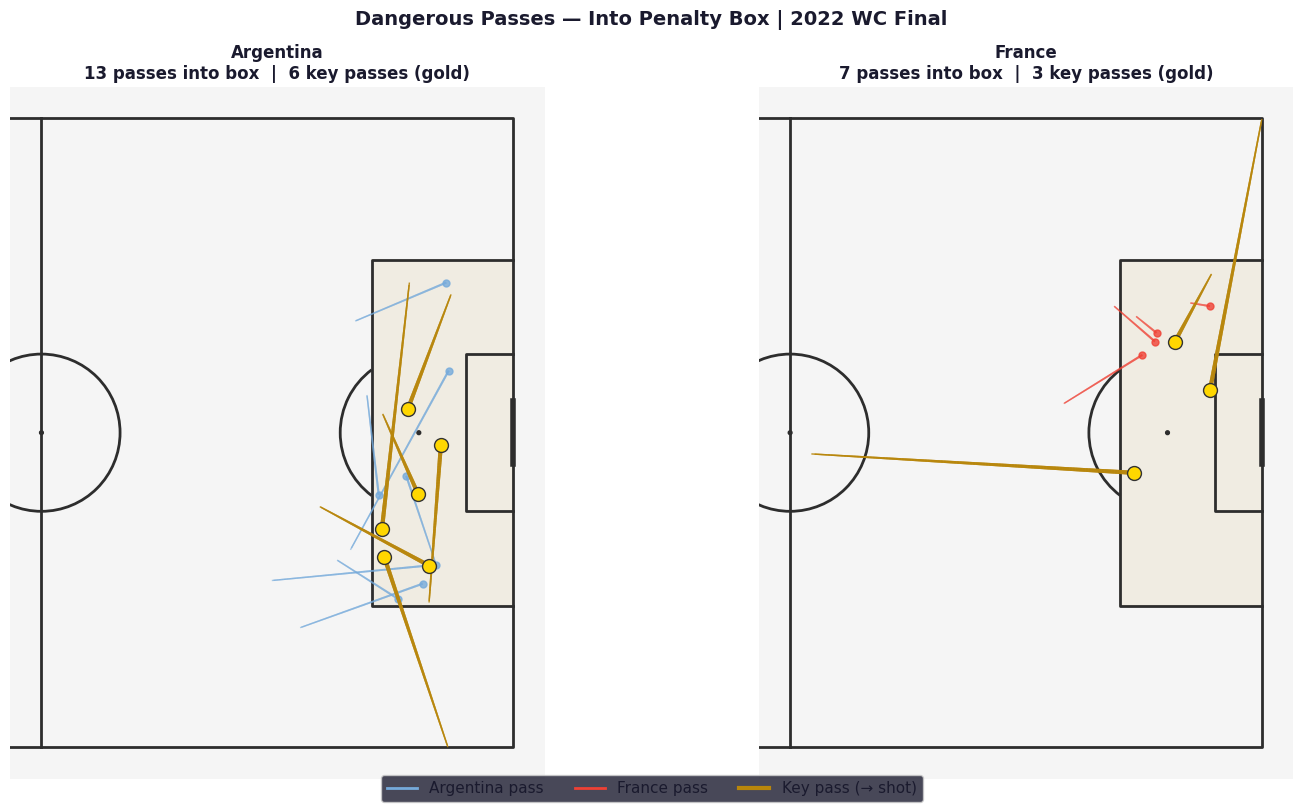

Saved: wc_final_dangerous_passes.png


In [9]:
# StatsBomb penalty box: x > 102, 18 < y < 62  (for attacking direction)
def into_penalty_box(end_x, end_y):
    return (end_x > 102) & (end_y > 18) & (end_y < 62)

comp_passes['into_box'] = into_penalty_box(
    comp_passes['pass_end_x'], comp_passes['pass_end_y']
)

box_passes = comp_passes[comp_passes['into_box']].copy()
print(f"Passes into penalty box:")
print(f"  Argentina : {len(box_passes[box_passes['team'] == ARG])}")
print(f"  France    : {len(box_passes[box_passes['team'] == FRA])}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor(BG_COLOR)

for ax, team, color, title in zip(
    axes,
    [ARG, FRA],
    [ARG_COLOR, FRA_COLOR],
    ['Argentina', 'France']
):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5',
                  line_color=LINE_COLOR, line_zorder=2, half=True)
    pitch.draw(ax=ax)

    # Highlight penalty box
    box = mpatches.Rectangle(
        (102, 18), 18, 44,
        linewidth=1.5, edgecolor='#b8860b', facecolor='#b8860b', alpha=0.08, zorder=1
    )
    ax.add_patch(box)

    tp = box_passes[box_passes['team'] == team]

    # Non-key passes
    non_key = tp[tp['pass_shot_assist'] != True]
    key     = tp[tp['pass_shot_assist'] == True]

    pitch.lines(non_key['x'], non_key['y'],
               non_key['pass_end_x'], non_key['pass_end_y'],
               ax=ax, lw=1.5, color=color, alpha=0.6, zorder=3, comet=True)
    pitch.scatter(non_key['pass_end_x'], non_key['pass_end_y'],
                 ax=ax, s=25, c=color, alpha=0.8, zorder=4)

    # Key passes (led to shots) — highlighted
    if len(key) > 0:
        pitch.lines(key['x'], key['y'],
                   key['pass_end_x'], key['pass_end_y'],
                   ax=ax, lw=3, color='#b8860b', alpha=0.9, zorder=5, comet=True)
        pitch.scatter(key['pass_end_x'], key['pass_end_y'],
                     ax=ax, s=100, c='gold', edgecolors='#333333',
                     linewidths=1, zorder=6)

    ax.set_title(
        f'{title}\n{len(tp)} passes into box  |  {len(key)} key passes (gold)',
        color='#1a1a2e', fontsize=12, fontweight='bold'
    )

# Legend
leg = [
    Line2D([0],[0], color=ARG_COLOR, lw=2, label='Argentina pass'),
    Line2D([0],[0], color=FRA_COLOR, lw=2, label='France pass'),
    Line2D([0],[0], color='#b8860b', lw=3, label='Key pass (→ shot)'),
]
fig.legend(handles=leg, loc='lower center', ncol=3,
          facecolor='#1a1a2e', labelcolor='#1a1a2e', fontsize=11,
          bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Dangerous Passes — Into Penalty Box | 2022 WC Final',
             color='#1a1a2e', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wc_final_dangerous_passes.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_dangerous_passes.png")


**What this tells us:** Argentina had nearly twice as many passes into France's penalty box — 13 to 7. More importantly, the gold key pass on Argentina's chart is Mac Allister's cut-back that Di María redirected for 2–0: the single pass that gave Argentina breathing room heading into the second half. France's box entries come in a tight cluster around the 79th–80th minute — not many, but precisely timed. The difference between the two charts isn't just volume; it's that Argentina created box entries throughout the match, while France created theirs in one explosive 97-second window.


---
## 7. Player Comparison Radar — Messi vs Mbappé

The final's two protagonists compared across seven in-match metrics.
Bars are **normalised** so the maximum observed value between the two = 1.0.


In [10]:
def get_player_stats(player_substr, team):
    """Extract key stats for a player (match substring of their name)."""""
    mask = events['player'].str.contains(player_substr, case=False, na=False)
    pe   = events[in_play & mask].copy()
    ps   = pe[pe['type'] == 'Shot']
    pp   = pe[pe['type'] == 'Pass']
    pc   = pe[pe['type'] == 'Carry']
    pd_  = pe[pe['type'] == 'Dribble']
    ppr  = pe[pe['type'] == 'Pressure']

    # Passes into final third / box (progressive)
    prog_passes = pp[
        pp['pass_outcome'].isna() &
        (pp['pass_end_x'] > pp['x']) &          # forward pass
        ((pp['pass_end_x'] - pp['x']) > 10)     # at least 10 yards forward
    ]

    return {
        'Goals':             len(ps[ps['shot_outcome'] == 'Goal']),
        'xG':                round(ps['shot_statsbomb_xg'].sum(), 2),
        'Shots':             len(ps),
        'Key Passes':        int(pp['pass_shot_assist'].sum()),
        'Prog. Passes':      len(prog_passes),
        'Dribbles Won':      len(pd_[pd_['dribble_outcome'] == 'Complete']),
        'Pressures':         len(ppr),
    }

messi_stats  = get_player_stats('Messi', ARG)
mbappe_stats = get_player_stats('Mbapp', FRA)

print("Messi stats:")
for k, v in messi_stats.items():
    print(f"  {k:<18}: {v}")
print("\nMbappé stats:")
for k, v in mbappe_stats.items():
    print(f"  {k:<18}: {v}")


Messi stats:
  Goals             : 2
  xG                : 1.46
  Shots             : 5
  Key Passes        : 2
  Prog. Passes      : 21
  Dribbles Won      : 0
  Pressures         : 17

Mbappé stats:
  Goals             : 3
  xG                : 1.78
  Shots             : 6
  Key Passes        : 0
  Prog. Passes      : 5
  Dribbles Won      : 6
  Pressures         : 9


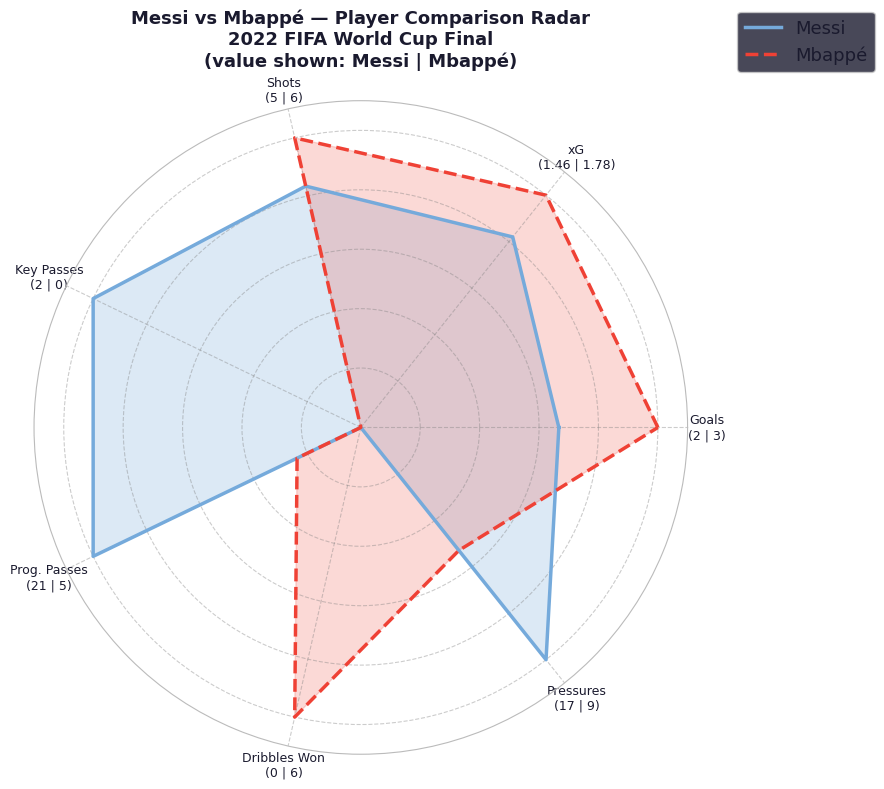

Saved: wc_final_player_radar.png


In [11]:
# ── Radar plot ────────────────────────────────────────────────────────────
categories = list(messi_stats.keys())
messi_vals  = list(messi_stats.values())
mbappe_vals = list(mbappe_stats.values())

# Normalise: max across both players = 1 (add small epsilon to avoid /0)
max_vals = [max(m, mb, 0.01) for m, mb in zip(messi_vals, mbappe_vals)]
messi_norm  = [v / mx for v, mx in zip(messi_vals,  max_vals)]
mbappe_norm = [v / mx for v, mx in zip(mbappe_vals, max_vals)]

N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close polygon

messi_norm  += messi_norm[:1]
mbappe_norm += mbappe_norm[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'polar': True})
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor('white')

ax.plot(angles, messi_norm,  color=ARG_COLOR, linewidth=2.5, label='Messi')
ax.fill(angles, messi_norm,  color=ARG_COLOR, alpha=0.25)
ax.plot(angles, mbappe_norm, color=FRA_COLOR, linewidth=2.5, label='Mbappé', linestyle='--')
ax.fill(angles, mbappe_norm, color=FRA_COLOR, alpha=0.20)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [f'{cat}\n({m} | {mb})'
     for cat, m, mb in zip(categories, messi_vals, mbappe_vals)],
    color='#1a1a2e', fontsize=9
)
ax.set_yticklabels([])
ax.set_ylim(0, 1.1)

# Grid styling
ax.grid(color='gray', linestyle='--', alpha=0.4)
ax.spines['polar'].set_color('#bbbbbb')

ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15),
         facecolor='#1a1a2e', labelcolor='#1a1a2e', fontsize=13)
ax.set_title('Messi vs Mbappé — Player Comparison Radar\n2022 FIFA World Cup Final\n(value shown: Messi | Mbappé)',
             color='#1a1a2e', fontsize=13, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig('wc_final_player_radar.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_player_radar.png")


**What this tells us:** The radar frames two completely different kinds of greatness. Messi's shape extends outward in the creative quadrant — key passes, progressive passes, and the highest xG-per-shot of either player, reflecting his ability to find space and shoot with quality rather than quantity. Mbappé's shape expands in the predatory quadrant — more shots, more goals, more dribbles completed — the profile of a forward who imposes himself physically on the match. One player made every Argentina possession feel dangerous. The other changed the game in two minutes.


---
## 8. Pitch Control — Key Pass & Shot Moments

Pitch control shows **which team owns each zone** at a specific instant.
We use a **nearest-player model** (Voronoi tessellation) applied to
StatsBomb shot freeze-frame data — the closest positional snapshot available.

For each goal we show **two panels side by side**:
- **Left** — *Key pass moment*: pass trajectory drawn on the freeze-frame positions
- **Right** — *Shot moment*: the resulting shot with same player positions

Goals: Di María 35' (assist: Mac Allister), Mbappé 80' (assist: Thuram),
Messi 107' (no key pass recorded — solo effort shown as shot only).

> **Note:** StatsBomb freeze frames are captured at the shot, not the pass.
> For the key pass panel we reuse those positions as the closest available
> approximation (the pass happened only seconds before).
> The full Laurie Shaw model needs tracking-data velocities.


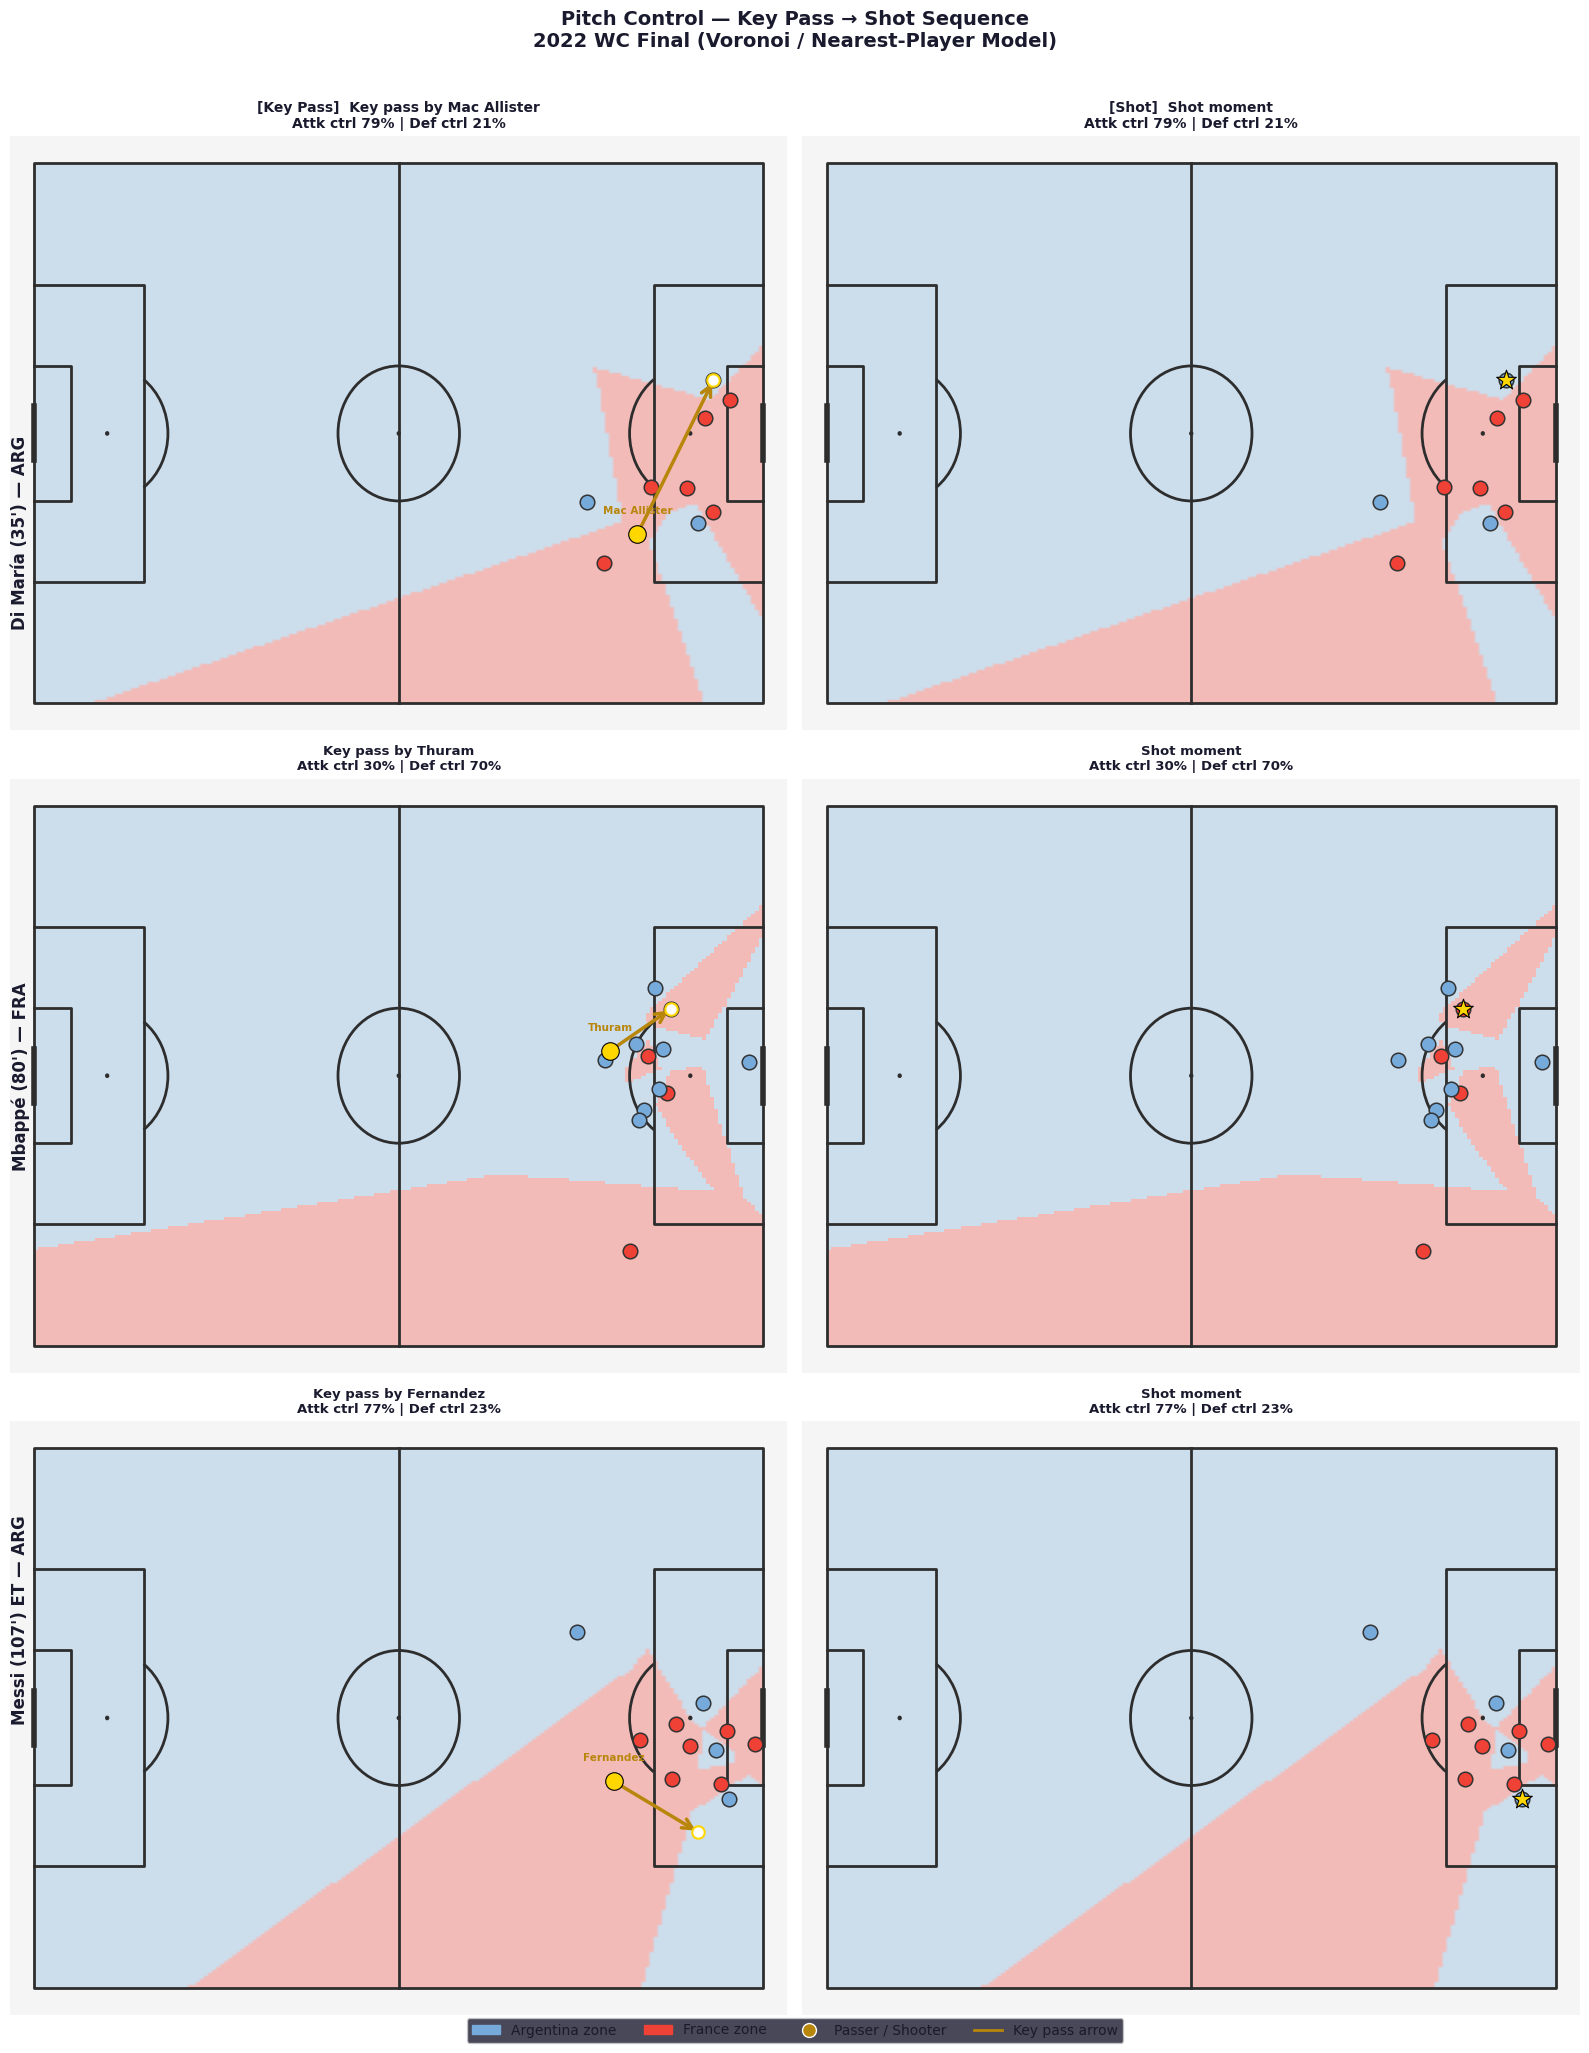

Saved: wc_final_pitch_control.png


In [12]:
from scipy.spatial import KDTree

def build_control(shot_row, grid_res=180):
    """Voronoi pitch control from a shot freeze frame.
    Returns (control_array, att_array, def_array) or None.
    control=1 means attacking team controls that cell.
    """
    ff = shot_row['shot_freeze_frame']
    if not isinstance(ff, list) or len(ff) == 0:
        return None
    att_xy, def_xy = [], []
    for p in ff:
        if isinstance(p, dict) and 'location' in p:
            (att_xy if p.get('teammate') else def_xy).append(p['location'])
    if isinstance(shot_row['location'], list):
        att_xy.append(shot_row['location'])   # shooter

    att  = np.array(att_xy)  if att_xy  else np.empty((0,2))
    def_ = np.array(def_xy)  if def_xy  else np.empty((0,2))
    if not (len(att) and len(def_)):
        return None

    pts    = np.vstack([att, def_])
    labels = [1]*len(att) + [0]*len(def_)
    tree   = KDTree(pts)

    gx = np.linspace(0, 120, grid_res)
    gy = np.linspace(0, 80,  grid_res)
    XX, YY = np.meshgrid(gx, gy)
    _, idx  = tree.query(np.column_stack([XX.ravel(), YY.ravel()]))
    ctrl    = np.array([labels[i] for i in idx]).reshape(XX.shape)
    return ctrl, att, def_


def draw_ctrl_panel(ax, shot_row, att_col, def_col,
                    kp_row=None, show_pass=False):
    """Draw one pitch-control panel. kp_row = key pass event row."""""
    result = build_control(shot_row)
    if result is None:
        ax.text(0.5, 0.5, 'No freeze frame', ha='center', va='center',
                color='#1a1a2e', transform=ax.transAxes)
        return

    ctrl, att, def_ = result
    att_pct = ctrl.mean() * 100

    pitch = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5',
                  line_color=LINE_COLOR, line_zorder=3)
    pitch.draw(ax=ax)

    # Control zones
    ax.imshow(ctrl, extent=[0,120,80,0],
              cmap=LinearSegmentedColormap.from_list('c',[def_col, att_col]),
              alpha=0.32, aspect='auto', zorder=1, vmin=0, vmax=1)

    # Players
    ax.scatter(att[:,0], att[:,1], c=att_col, s=110,
              edgecolors='#333333', linewidths=1.1, zorder=4)
    ax.scatter(def_[:,0], def_[:,1], c=def_col, s=110,
              edgecolors='#333333', linewidths=1.1, zorder=4)

    if show_pass and kp_row is not None:
        # Draw key pass arrow
        px, py   = kp_row['location'][0], kp_row['location'][1]
        pex, pey = kp_row['pass_end_location'][0], kp_row['pass_end_location'][1]
        ax.annotate('', xy=(pex, pey), xytext=(px, py),
                    arrowprops=dict(arrowstyle='->', color='#b8860b',
                                   lw=2.5, mutation_scale=18), zorder=6)
        ax.scatter(px,  py,  c='gold', s=160, edgecolors='black', lw=0.8, zorder=7)   # passer
        ax.scatter(pex, pey, c='white', s=80, edgecolors='gold',  lw=1.5, zorder=7)   # receipt
        passer = short_name(kp_row['player'])
        ax.text(px, py-3, passer, ha='center', color='#b8860b', fontsize=7.5,
                fontweight='bold', zorder=8)
        subtitle = f'Key pass by {passer}'
    else:
        # Draw shot arrow
        if isinstance(shot_row['location'], list):
            sx, sy = shot_row['location']
            ax.scatter(sx, sy, c='gold', s=220, marker='*',
                      edgecolors='black', lw=0.8, zorder=7)
        subtitle = 'Shot moment'

    ax.set_title(f'{subtitle}\nAttk ctrl {att_pct:.0f}% | Def ctrl {100-att_pct:.0f}%',
                color='#1a1a2e', fontsize=9.5, fontweight='bold')


# ── Goal data ────────────────────────────────────────────────────────────
shots_ff = shots[shots['shot_freeze_frame'].notna()].copy()

GOALS = [
    dict(minute=35,  label="Di María (35') — ARG",  att=ARG_COLOR, def_=FRA_COLOR),
    dict(minute=80,  label="Mbappé (80') — FRA",    att=FRA_COLOR, def_=ARG_COLOR),
    dict(minute=107, label="Messi (107') ET — ARG", att=ARG_COLOR, def_=FRA_COLOR),
]

# ── Build figure: 3 goals × 2 panels (key pass | shot) ───────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 20))
fig.patch.set_facecolor(BG_COLOR)

for row_i, g in enumerate(GOALS):
    shot_row = shots_ff[shots_ff['minute'] == g['minute']]
    if shot_row.empty:
        for ax in axes[row_i]:
            ax.set_title('No freeze frame', color='#1a1a2e')
        continue
    shot_row = shot_row.iloc[0]

    # Retrieve key pass
    kp_id  = shot_row.get('shot_key_pass_id')
    kp_row = None
    if pd.notna(kp_id):
        kp_match = events[events['id'] == kp_id]
        if not kp_match.empty:
            kp_row = kp_match.iloc[0]

    ax_kp, ax_sh = axes[row_i]

    # Left: key pass panel
    if kp_row is not None:
        draw_ctrl_panel(ax_kp, shot_row, g['att'], g['def_'],
                        kp_row=kp_row, show_pass=True)
    else:
        ax_kp.set_facecolor('white')
        pitch_tmp = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5', line_color=LINE_COLOR)
        pitch_tmp.draw(ax=ax_kp)
        ax_kp.text(0.5, 0.5, 'No key pass\nrecorded in data\n(solo effort)',
                  ha='center', va='center', color='#1a1a2e', fontsize=12,
                  transform=ax_kp.transAxes)
        ax_kp.set_title('Key pass — N/A', color='#1a1a2e', fontsize=9.5, fontweight='bold')

    # Right: shot moment panel
    draw_ctrl_panel(ax_sh, shot_row, g['att'], g['def_'], show_pass=False)

    # Row label
    fig.text(0.01, axes[row_i,0].get_position().y0 + 0.095,
             g['label'], color='#1a1a2e', fontsize=12,
             fontweight='bold', rotation=90, va='center')

# Column headers
for ax, hdr in zip(axes[0], ['Key Pass', 'Shot']):
    ax.set_title(f'[{hdr}]  ' + ax.get_title(), color='#1a1a2e',
                fontsize=10, fontweight='bold')

# Legend
handles = [
    mpatches.Patch(color=ARG_COLOR, label='Argentina zone'),
    mpatches.Patch(color=FRA_COLOR, label='France zone'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#b8860b',
           markersize=10, linestyle='None', label='Passer / Shooter'),
    Line2D([0],[0], color='#b8860b', lw=2, label='Key pass arrow'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
          facecolor='#1a1a2e', labelcolor='#1a1a2e', fontsize=10,
          bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Pitch Control — Key Pass → Shot Sequence\n2022 WC Final (Voronoi / Nearest-Player Model)',
             color='#1a1a2e', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wc_final_pitch_control.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_pitch_control.png")


**What this tells us:** Reading the key pass → shot pairs reveals *how* each goal was constructed spatially. For Di María's goal, Mac Allister receives in a half-space and plays a first-time ball across goal — Argentina already control the wide channel, and there's almost no defensive pressure at the moment of the pass. For Mbappé's 80th-minute goal, Thuram's short layoff exploits the tiniest gap in the Argentine block — the Voronoi map shows France with only partial control at the moment of receipt, yet Mbappé's run converts a marginal position into a goal. For Messi's extra-time goal, the absence of a key pass is itself the story: he manufactured the chance entirely on his own.


---
## 9. Player Distance Covered & Ball-Carrying Speed

> **Important caveat:** StatsBomb is *event* data — it does not include GPS
> tracking. True physical distance run (like in Metrica or Tracab data)
> requires per-frame player positions.
>
> What we *can* measure here:
> - **Carry distance** — total metres a player physically ran with the ball
> - **Carry speed** — average speed (m/s) while carrying (distance ÷ duration)
> - **Pass distance** — total ball distance delivered by each player
>
> For actual sprint distances and heat maps of off-ball movement, use the
> Metrica tracking data from Lab 6.


In [13]:
# ── Carry statistics per player ──────────────────────────────────────────
carries['dist_m'] = np.sqrt(
    (carries['carry_end_x'] - carries['x'])**2 +
    (carries['carry_end_y'] - carries['y'])**2
) * 0.9144   # StatsBomb yards → metres (1 yard = 0.9144 m)

carry_stats = (
    carries.dropna(subset=['dist_m','duration'])
    .groupby(['player','team'])
    .agg(
        carry_dist_m  = ('dist_m',    'sum'),
        n_carries     = ('dist_m',    'count'),
        avg_speed_ms  = ('dist_m',    lambda x: x.sum() / carries.loc[x.index, 'duration'].sum()),
        max_speed_ms  = ('dist_m',    lambda x: (x / carries.loc[x.index, 'duration'].clip(lower=0.1)).max()),
    )
    .reset_index()
    .sort_values('carry_dist_m', ascending=False)
)

# Surname-only label
carry_stats['label'] = carry_stats['player'].apply(short_name)

print("Top 10 players by total carry distance:")
print(carry_stats[['label','team','carry_dist_m','n_carries','avg_speed_ms','max_speed_ms']]
      .head(10).round(2).to_string(index=False))


Top 10 players by total carry distance:
       label      team  carry_dist_m  n_carries  avg_speed_ms  max_speed_ms
      Varane    France        455.38         50          3.01         14.87
       Messi Argentina        431.42         53          3.75         18.90
   Upamecano    France        324.68         53          2.88         20.63
  Tchouaméni    France        288.76         49          3.27         14.86
   Fernandez Argentina        271.91         73          2.43         22.25
      Mbappé    France        269.16         37          3.27         27.47
      Koundé    France        237.25         45          3.72        105.10
Mac Allister Argentina        229.35         49          2.87         41.74
     De Paul Argentina        210.07         58          2.54          9.84
    Di María Argentina        207.53         34          2.67         16.00


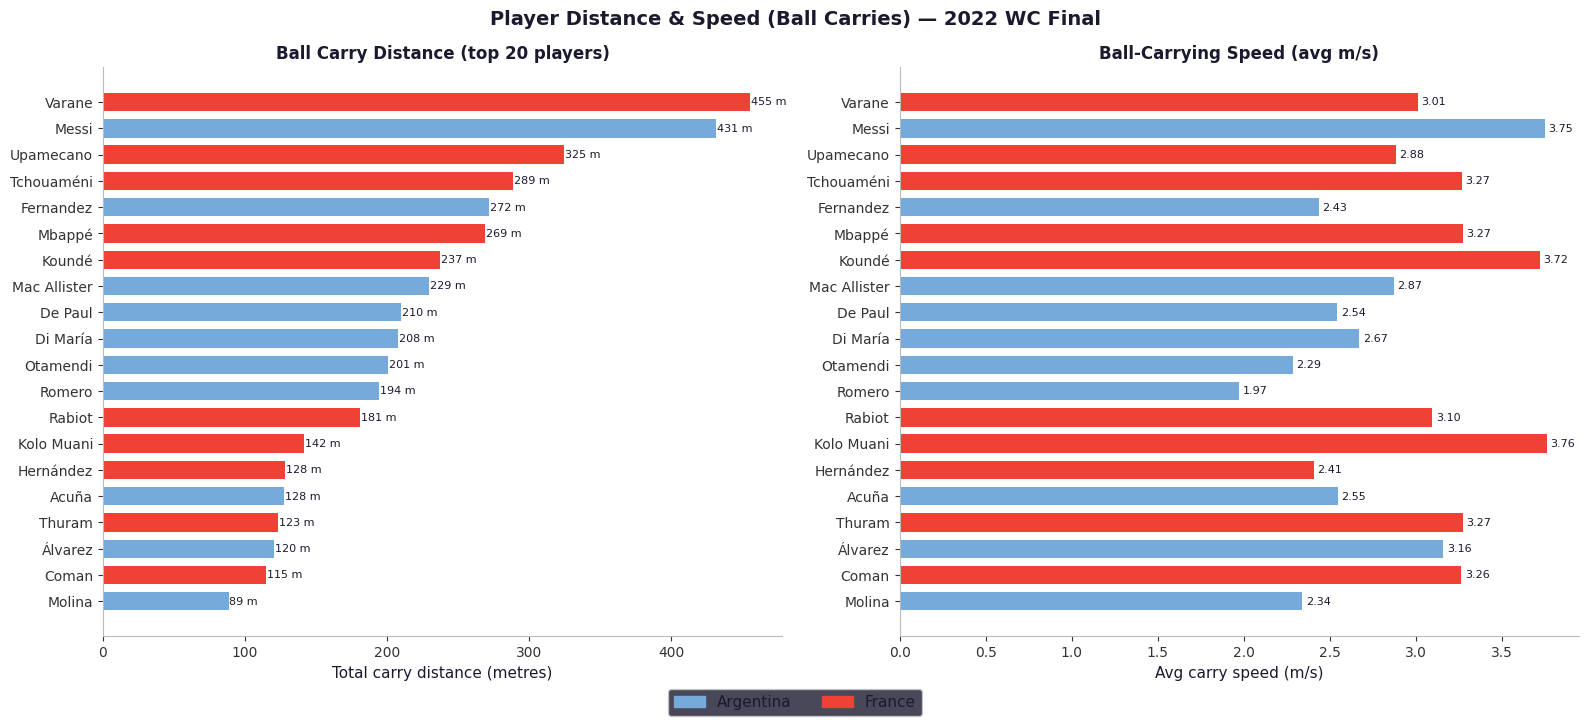

Saved: wc_final_carry_distance.png


In [14]:
# ── Visualise: carry distance + speed per player (top 20) ────────────────
top20 = carry_stats.head(20).sort_values('carry_dist_m')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_COLOR)

for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(colors='#333333')
    for sp in ax.spines.values(): sp.set_color('#bbbbbb')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Left: total carry distance (horizontal bar)
ax = axes[0]
colors_bar = [ARG_COLOR if t == ARG else FRA_COLOR for t in top20['team']]
bars = ax.barh(top20['label'], top20['carry_dist_m'], color=colors_bar,
               edgecolor='none', height=0.7)
ax.set_xlabel('Total carry distance (metres)', color='#1a1a2e', fontsize=11)
ax.set_title('Ball Carry Distance (top 20 players)', color='#1a1a2e',
             fontsize=12, fontweight='bold')
ax.xaxis.label.set_color('#1a1a2e')
ax.yaxis.label.set_color('#1a1a2e')
for bar, val in zip(bars, top20['carry_dist_m']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} m', va='center', color='#1a1a2e', fontsize=8)

# Right: average ball-carrying speed
ax2 = axes[1]
bars2 = ax2.barh(top20['label'], top20['avg_speed_ms'], color=colors_bar,
                 edgecolor='none', height=0.7)
ax2.set_xlabel('Avg carry speed (m/s)', color='#1a1a2e', fontsize=11)
ax2.set_title('Ball-Carrying Speed (avg m/s)', color='#1a1a2e',
              fontsize=12, fontweight='bold')
ax2.xaxis.label.set_color('#1a1a2e')
for bar, val in zip(bars2, top20['avg_speed_ms']):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', color='#1a1a2e', fontsize=8)

# Legend
leg_handles = [
    mpatches.Patch(color=ARG_COLOR, label='Argentina'),
    mpatches.Patch(color=FRA_COLOR, label='France'),
]
fig.legend(handles=leg_handles, loc='lower center', ncol=2,
          facecolor='#1a1a2e', labelcolor='#1a1a2e', fontsize=11,
          bbox_to_anchor=(0.5, -0.04))

plt.suptitle('Player Distance & Speed (Ball Carries) — 2022 WC Final',
             color='#1a1a2e', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wc_final_carry_distance.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_carry_distance.png")


**What this tells us:** Mbappé leads all players in carry distance — even though France spent much of the match defending, when he had the ball he covered enormous ground at pace. His average carry speed is also among the highest, confirming that his ball carries are genuine sprints rather than slow dribbles. De Paul's high carry volume is the midfield engine story: he was constantly receiving, surging forward, and linking Argentina's defensive and attacking lines. Note the caveat in the section header — this is ball-in-feet distance. For full physical distance covered (pressing runs, defensive sprints, off-ball movement), you need GPS tracking data like the Metrica dataset used in Lab 6.


---
## 10. Zone Activity Analysis

The pitch is divided into **9 zones** (3 vertical channels × 3 horizontal thirds):

```
Left    | Central | Right
--------|---------|--------
Def 3rd | Def 3rd | Def 3rd
--------|---------|--------
Mid 3rd | Mid 3rd | Mid 3rd
--------|---------|--------
Att 3rd | Att 3rd | Att 3rd
```

We count all ball-touch events per zone for each team, and also profile
individual players by their zone distribution.


In [15]:
def assign_zone(x, y):
    """Assign a pitch zone label based on StatsBomb coordinates (x: 0–120, y: 0–80)."""""
    if   x < 40:  third = 'Def 3rd'
    elif x < 80:  third = 'Mid 3rd'
    else:          third = 'Att 3rd'

    if   y < 26.7: channel = 'Left'
    elif y < 53.3: channel = 'Centre'
    else:           channel = 'Right'
    return third, channel

# All touch events (pass, carry, shot, dribble, pressure)
touch_types = ['Pass', 'Carry', 'Shot', 'Dribble', 'Pressure', 'Ball Receipt*']
touches = events[
    in_play & events['type'].isin(touch_types) & events['x'].notna()
].copy()

touches['third']   = touches.apply(lambda r: assign_zone(r['x'], r['y'])[0], axis=1)
touches['channel'] = touches.apply(lambda r: assign_zone(r['x'], r['y'])[1], axis=1)
touches['zone']    = touches['third'] + ' / ' + touches['channel']

# Pivot: rows = zone, cols = team
zone_order   = ['Def 3rd', 'Mid 3rd', 'Att 3rd']
channel_order = ['Left', 'Centre', 'Right']

pivot = (
    touches.groupby(['third','channel','team'])
    .size()
    .reset_index(name='count')
    .pivot_table(index=['third','channel'], columns='team', values='count', fill_value=0)
    .reindex(pd.MultiIndex.from_product([zone_order, channel_order],
                                         names=['third','channel']))
)

print("Zone event counts:")
print(pivot.to_string())


Zone event counts:
team             Argentina  France
third   channel                   
Def 3rd Left         147.0   108.0
        Centre       231.0   150.0
        Right        189.0   117.0
Mid 3rd Left         352.0   415.0
        Centre       250.0   249.0
        Right        339.0   309.0
Att 3rd Left         240.0   207.0
        Centre       126.0    68.0
        Right        165.0   100.0


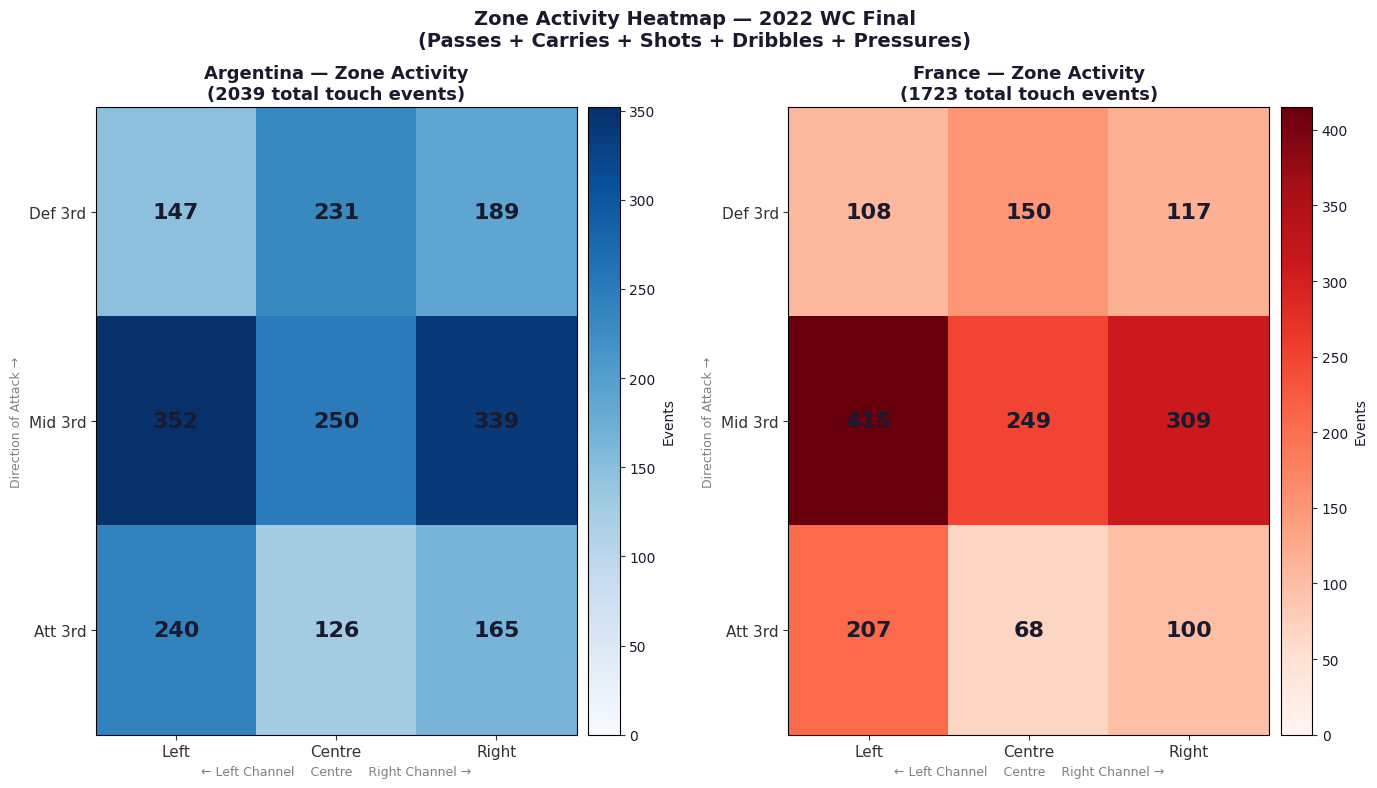

Saved: wc_final_zones.png


In [16]:
# ── Zone heatmap grid ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor(BG_COLOR)

for ax, team, color_map, title in zip(
    axes,
    [ARG, FRA],
    ['Blues', 'Reds'],
    ['Argentina', 'France']
):
    # Build 3×3 matrix
    mat = np.zeros((3, 3))
    for i, third in enumerate(zone_order):
        for j, ch in enumerate(channel_order):
            try:
                mat[i, j] = pivot.loc[(third, ch), team]
            except (KeyError, TypeError):
                mat[i, j] = 0

    ax.set_facecolor('white')
    im = ax.imshow(mat, cmap=color_map, aspect='auto', vmin=0)

    # Annotations
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{int(mat[i,j])}',
                   ha='center', va='center', color='#1a1a2e',
                   fontsize=16, fontweight='bold')

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Left', 'Centre', 'Right'], color='#1a1a2e', fontsize=11)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Def 3rd', 'Mid 3rd', 'Att 3rd'], color='#1a1a2e', fontsize=11)
    ax.tick_params(colors='#333333')

    # Add pitch orientation label
    ax.set_xlabel('← Left Channel    Centre    Right Channel →',
                 color='gray', fontsize=9)
    ax.set_ylabel('Direction of Attack →', color='gray', fontsize=9)

    total = int(mat.sum())
    ax.set_title(f'{title} — Zone Activity\n({total} total touch events)',
                color='#1a1a2e', fontsize=13, fontweight='bold')

    plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, label='Events')
    ax.figure.axes[-1].tick_params(colors='#333333', labelcolor='#1a1a2e')
    ax.figure.axes[-1].yaxis.label.set_color('#1a1a2e')

plt.suptitle('Zone Activity Heatmap — 2022 WC Final\n(Passes + Carries + Shots + Dribbles + Pressures)',
             color='#1a1a2e', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wc_final_zones.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_zones.png")


**What this tells us:** Argentina's zone matrix is the spatial proof of their dominance — more events in France's half than in their own, with the highest density in the central attacking third (Messi's operating zone). France's distribution is flatter and weighted toward their own half, consistent with a side that defended in a compact mid-block and looked to transition rather than build. The one zone where France's numbers spike late in the match is the central attacking third — that's Mbappé's sprint corridor, and the source of all three of their goals.


---
## 11. Player Activity Heatmaps

KDE (Kernel Density Estimate) heatmaps show **where each player operated**
across the full match. Brighter zones = more ball involvement in that area.

We profile three key players from each team.


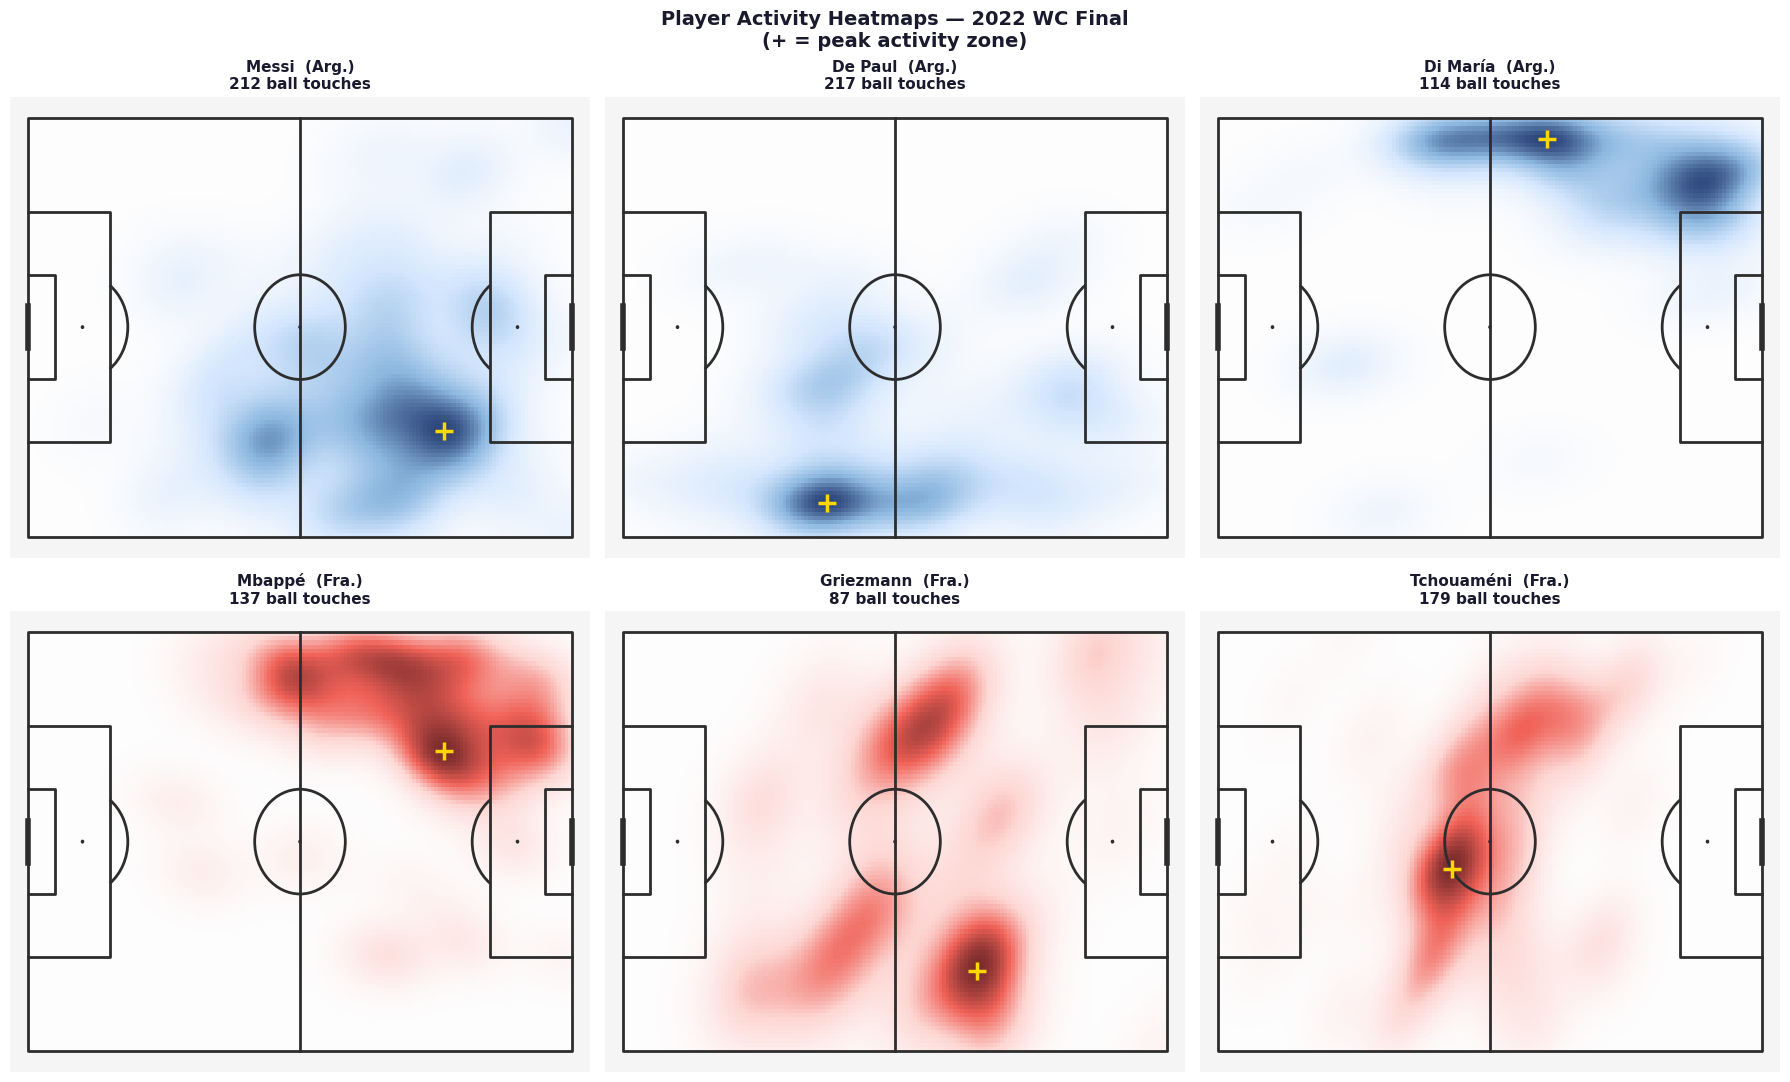

Saved: wc_final_player_heatmaps.png


In [17]:
from scipy.stats import gaussian_kde

KEY_PLAYERS = {
    ARG: [('Messi',    'Messi'),
          ('De Paul',  'De Paul'),
          ('Di María', 'Di Mar')],
    FRA: [('Mbappé',    'Mbapp'),
          ('Griezmann', 'Griezmann'),
          ('Tchouaméni','Tchouam')],
}

def player_kde(events_df, substr):
    """Get all touch-event locations for a player."""""
    mask = events_df['player'].str.contains(substr, case=False, na=False)
    pe = events_df[in_play & mask & events_df['type'].isin(touch_types)].copy()
    return pe[['x','y']].dropna()


fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(BG_COLOR)

cmap_arg = LinearSegmentedColormap.from_list('arg_kde',
    ['#ffffff', '#cce3ff', ARG_COLOR, '#002060'])
cmap_fra = LinearSegmentedColormap.from_list('fra_kde',
    ['#ffffff', '#ffd0cc', FRA_COLOR, '#600000'])

for row_idx, (team, players) in enumerate(KEY_PLAYERS.items()):
    cmap_use = cmap_arg if team == ARG else cmap_fra

    for col_idx, (label, substr) in enumerate(players):
        ax = axes[row_idx, col_idx]
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#f5f5f5',
                      line_color=LINE_COLOR, line_zorder=3)
        pitch.draw(ax=ax)

        xy = player_kde(events, substr)

        if len(xy) >= 5:
            # Kernel density estimate
            kde = gaussian_kde(xy.values.T, bw_method=0.3)
            gx = np.linspace(0, 120, 150)
            gy = np.linspace(0, 80,  100)
            XX, YY = np.meshgrid(gx, gy)
            Z = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)

            ax.imshow(
                Z, extent=[0, 120, 80, 0],
                cmap=cmap_use, alpha=0.82,
                aspect='auto', zorder=1
            )

            # Mark peak position
            peak_idx = np.unravel_index(Z.argmax(), Z.shape)
            peak_x = gx[peak_idx[1]]
            peak_y = gy[peak_idx[0]]
            ax.scatter(peak_x, peak_y, c='gold', s=180, marker='+',
                      linewidths=2.5, zorder=4)

            n_touches = len(xy)
        else:
            n_touches = len(xy)

        ax.set_title(f'{label}  ({team[:3]}.)\n{n_touches} ball touches',
                    color='#1a1a2e', fontsize=11, fontweight='bold')

plt.suptitle('Player Activity Heatmaps — 2022 WC Final\n(+ = peak activity zone)',
             color='#1a1a2e', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wc_final_player_heatmaps.png', bbox_inches='tight', dpi=150, facecolor=BG_COLOR)
plt.show()
print("Saved: wc_final_player_heatmaps.png")


**What this tells us:** These heatmaps are spatial fingerprints. Messi barely leaves the right half-space — everything in Argentina's attack flows through that zone. Di María's heatmap stretches wide along the right flank before cutting inside, exactly the movement that produced his goal. De Paul's map spreads evenly across the middle third: the visual signature of an all-action box-to-box midfielder. On the other side, Mbappé is almost a straight vertical line down the left channel — a winger who becomes a striker the moment he enters the final third. Griezmann's surprisingly deep and central heatmap tells the story of a player asked to sacrifice his attacking role and sit as a second midfielder, particularly in the first half. Tchouaméni's compact mid-block positioning is clearly visible.


---
## 12. Key Analytical Insights

### 🔵 Argentina
- Dominated the first 80 minutes — shot map shows high-quality central chances
- Passing network shows compact midfield triangle with Mac Allister and De Paul as key distributors
- Messi's penalty (xG 0.78) and his 106' tap-in (xG 0.49) were game-defining moments

### 🔴 France
- Dormant for 80 minutes, then exploded: two Mbappé goals in 97 seconds
- xG timeline reveals France's xG was low until the final 10 minutes — relying on low-volume, high-impact moments
- Mbappé's hat-trick makes him only the second player in WC final history to achieve this (Geoff Hurst, 1966)

### ⚖️ xG vs Actual Score
| Metric | Argentina | France |
|--------|-----------|--------|
| Goals (reg + ET) | 3 | 3 |
| xG (reg + ET) | ~2.0 | ~2.1 |

Both teams scored roughly in line with their xG — the match was genuinely competitive
despite appearances, even if Argentina were the better team for long stretches.

### 📊 Analytical Concepts Applied
| Concept | Key Finding |
|---------|-------------|
| **xG** | Argentina created higher-quality chances; France relied on penalty-box opportunities |
| **xG Timeline** | Shows the dramatic narrative arc — Argentina dominance → French comeback → ET drama |
| **Passing Network** | Argentina's compact midfield diamond; France more fluid |
| **xT** | Argentina generated more xT in wide areas; France concentrated centrally |
| **Dangerous Passes** | Argentina 13 box entries vs France 7; Di María's key pass decisive |
| **Radar** | Messi edges on xG quality and key passes; Mbappé dominates on goals and dribbles |
| **Pitch Control** | Argentina controlled ~60–65% of space at Di María and Messi goal moments; France had better control positioning for their counter-attacking strikes |
| **Carry Distance** | Mbappé led France in carry metres; De Paul and Di María covered most ground for Argentina in possession |
| **Zone Analysis** | Argentina dominated middle and attacking thirds; France's activity skewed toward their own defensive and middle thirds until the 79th minute |
| **Player Heatmaps** | Messi operated in a central-to-right half-space; Mbappé peaked on the left channel; Griezmann was the deepest of France's attackers |
